In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading and Data Preprocessing - I

#### Checking *Stock Index and Monthly NPS score*

In [123]:
stock_nps = pd.read_excel('/content/Media data-Sale Calendar-NPS Scores_Data.xlsx', sheet_name=2)

In [124]:
stock_nps.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,July'23,Aug'23,Sept'23,Oct'23,Nov'23,Dec'23,Jan'24,Feb'24,Mar'24,Apr'24,May'24,June'24
1,NPS,54.599588,59.987101,46.925419,44.398389,47.0,45.8,47.093031,50.327406,49.02055,51.827605,47.306951,50.516687
2,Stock Index,1177,1206,1101,1210,1233,1038,1052,1222,1015,1242,1228,1194


In [125]:
# Drop first row and set axis as the second row
stock_nps = stock_nps.drop(stock_nps.index[:0])
stock_nps = stock_nps.set_axis(stock_nps.iloc[0], axis=1)
stock_nps = stock_nps.drop(stock_nps.index[0])

In [126]:
stock_nps = stock_nps.T.reset_index(drop=True)

In [127]:
stock_nps = stock_nps.set_axis(stock_nps.iloc[0], axis=1)
stock_nps = stock_nps.drop(stock_nps.index[0])

In [128]:
stock_nps

,NPS,Stock Index
1,54.599588,1177
2,59.987101,1206
3,46.925419,1101
4,44.398389,1210
5,47.0,1233
6,45.8,1038
7,47.093031,1052
8,50.327406,1222
9,49.02055,1015
10,51.827605,1242


#### Checking *Holidays list in Canada*

In [129]:
canada_holiday = pd.read_excel('Canada Holiday List.xlsx')

In [130]:
canada_holiday.head()

,Occassion,Day
0,Canada Day,"July 1, 2023"
1,Civic Holiday,"August 3, 2023"
2,Labour Day,"September 7, 2023"
3,Thanksgiving,"October 12, 2023"
4,Halloween,"October 31, 2023"


In [131]:
# Convert 'Day of canada_holiday' to datetime
canada_holiday['Day'] = pd.to_datetime(canada_holiday['Day'])

# Extract the week number
canada_holiday['Week Number'] = canada_holiday['Day'].dt.isocalendar().week

# Print the updated DataFrame
canada_holiday.head()

,Occassion,Day,Week Number
0,Canada Day,2023-07-01,26
1,Civic Holiday,2023-08-03,31
2,Labour Day,2023-09-07,36
3,Thanksgiving,2023-10-12,41
4,Halloween,2023-10-31,44


In [132]:
canada_holiday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occassion    23 non-null     object        
 1   Day          23 non-null     datetime64[ns]
 2   Week Number  23 non-null     UInt32        
dtypes: UInt32(1), datetime64[ns](1), object(1)
memory usage: 615.0+ bytes


No null values or missing data.

#### Checking *Main Consumer file*

In [133]:
cust_orders = pd.read_csv('Customers_Orders_Data.csv')

In [134]:
cust_orders.head()

,Unnamed: 0,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,cust_id,pincode,product_mrp,product_procurement_sla
0,0,ACCCX3S58G7B5F6P,2023-10-17 15:11:54,3.419301e+15,3.419301e+15,6400,1,\N,\N,COD,5,-1.01299130778588E+018,-7.79175582905735E+018,7190,0
1,1,ACCCX3S58G7B5F6P,2023-10-19 10:07:22,1.420831e+15,1.420831e+15,6900,1,\N,\N,COD,7,-8.99032457905512E+018,7.33541149097431E+018,7190,0
2,2,ACCCX3S5AHMF55FV,2023-10-20 15:45:56,2.421913e+15,2.421913e+15,1990,1,\N,\N,COD,10,-1.0404429420466E+018,-7.47768776228657E+018,2099,3
3,3,ACCCX3S5AHMF55FV,2023-10-14 12:05:15,4.416592e+15,4.416592e+15,1690,1,\N,\N,Prepaid,4,-7.60496084352714E+018,-5.83593163877661E+018,2099,3
4,4,ACCCX3S5AHMF55FV,2023-10-17 21:25:03,4.419525e+15,4.419525e+15,1618,1,\N,\N,Prepaid,6,2.8945572083453E+018,5.34735360997242E+017,2099,3


In [135]:
cust_orders = cust_orders.drop(cust_orders.columns[0], axis=1)

In [136]:
for col in ['order_item_id', 'sla', 'cust_id', 'product_mrp', 'gmv']:
    try:
        cust_orders[col] = pd.to_numeric(cust_orders[col], errors='coerce')
    except:
        print(f"Could not convert column {col} to numeric. Dropping rows with errors.")
        cust_orders = cust_orders.dropna(subset=[col])

cust_orders = cust_orders.astype({'order_item_id': 'float64', 'sla': 'float64', 'cust_id': 'float64'})

In [137]:
cust_orders = cust_orders.dropna()

In [138]:
cust_orders['deliverybdays'] = cust_orders['deliverybdays'].replace(to_replace=[value for value in cust_orders['deliverybdays'].unique() if value != 0], value=0)
cust_orders['deliverycdays'] = cust_orders['deliverycdays'].replace(to_replace=[value for value in cust_orders['deliverycdays'].unique() if value != 0], value=0)


In [139]:
# Reaarange in ascending order of order_date and reset index
cust_orders = cust_orders.sort_values(by='order_date', ascending=True).reset_index(drop=True)

# Duplicates in order_date with exact same datetime in gmvY and drop the redundant rows
cust_orders = cust_orders.sort_values('order_date')  # Sort by order_date to ensure proper grouping
cust_orders = cust_orders.drop_duplicates(subset=['order_date'], keep='first')

In [140]:
cust_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1152699 entries, 0 to 1643918
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   fsn_id                   1152699 non-null  object 
 1   order_date               1152699 non-null  object 
 2   order_id                 1152699 non-null  float64
 3   order_item_id            1152699 non-null  float64
 4   gmv                      1152699 non-null  float64
 5   units                    1152699 non-null  int64  
 6   deliverybdays            1152699 non-null  int64  
 7   deliverycdays            1152699 non-null  int64  
 8   order_payment_type       1152699 non-null  object 
 9   sla                      1152699 non-null  float64
 10  cust_id                  1152699 non-null  float64
 11  pincode                  1152699 non-null  object 
 12  product_mrp              1152699 non-null  int64  
 13  product_procurement_sla  1152699 non-null  int6

We dropped unnamed column, dropped the null values, replaced '\N' to 0 and converted mixed dtype columns to float64 dtype.

#### Checking *Media Data file*

In [141]:
media_dat = pd.read_excel('/content/Media data-Sale Calendar-NPS Scores_Data.xlsx')

In [142]:
media_dat.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,"Investment in various media heads, INR Cr.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
2,NaN,2023,7,17.061775,0.21533,2.533014,7.41427,0.000933,1.327278,0.547254,5.023697,NaN,NaN
3,NaN,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,NaN,NaN
4,NaN,2023,9,96.25438,3.879504,1.356528,62.787651,0.610292,16.37999,5.038266,6.202149,NaN,NaN


In [143]:
# Drop first two rows and set axis as the third row
media_dat = media_dat.drop(media_dat.index[:1])
media_dat = media_dat.set_axis(media_dat.iloc[0], axis=1)
media_dat = media_dat.drop(media_dat.index[0])

# Reset index and drop the first column
media_dat = media_dat.reset_index(drop=True)
media_dat = media_dat.drop(media_dat.columns[0], axis=1)

In [144]:
# Fill NaN values with 0
media_dat = media_dat.fillna(0)

In [145]:
# Reset the index to start from 1
media_dat.index = media_dat.index + 1

In [146]:
media_dat.head()

1,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
1,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.0
2,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.0
3,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.0
4,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.0,0.0
5,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.0,0.0


#### Checking *SKU Details*

In [147]:
sku_det = pd.read_csv('/content/SKU_details.csv')

In [148]:
sku_det.head()

,fsn_id,product_analytic_super_category,product_analytic_category,product_analytic_sub_category,product_analytic_vertical
0,ACCCX3S58G7B5F6P,CE,CameraAccessory,CameraAccessory,CameraTripod
1,ACCCX3S5AHMF55FV,CE,CameraAccessory,CameraAccessory,CameraTripod
2,ACCCX3S5JGAJETYR,CE,CameraAccessory,CameraAccessory,CameraTripod
3,ACCCX3SG2GG9YYAH,CE,CameraAccessory,CameraAccessory,Lens
4,ACCCX3SGAR6NNBMR,CE,CameraAccessory,CameraAccessory,Lens


In [149]:
sku_det.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21219 entries, 0 to 21218
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   fsn_id                           21219 non-null  object
 1   product_analytic_super_category  21219 non-null  object
 2   product_analytic_category        21219 non-null  object
 3   product_analytic_sub_category    21219 non-null  object
 4   product_analytic_vertical        21219 non-null  object
dtypes: object(5)
memory usage: 829.0+ KB


No null values or missing data.

#### Checking *2023 Weather file*

In [150]:
weather_2023 = pd.read_csv('/content/weather2023-2024.csv')

In [151]:
weather_2023.head()

,order_date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
0,2023-01-01,0.0,-8.5,-4.3,22.3,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,2023-01-02,3.0,-3.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2023-01-03,2.5,-4.0,-0.8,18.8,0.0,24.0,0.0,24.0,0.0,NaN,NaN
3,2023-01-04,2.5,0.0,1.3,16.7,0.0,0.0,1.0,1.0,0.0,NaN,NaN
4,2023-01-05,-10.0,-13.5,-11.8,29.8,0.0,0.0,3.0,3.0,1.0,NaN,NaN


In [152]:
# Drop first 22 rows and set axis as the 23rd row
weather_2023 = weather_2023.drop(weather_2023.index[:23])
weather_2023 = weather_2023.set_axis(weather_2023.iloc[0], axis=1)
weather_2023 = weather_2023.drop(weather_2023.index[0])

In [154]:
weather_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 24 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   2023-01-24  707 non-null    object 
 1   nan         431 non-null    float64
 2   nan         400 non-null    float64
 3   nan         400 non-null    float64
 4   nan         400 non-null    float64
 5   nan         400 non-null    float64
 6   nan         444 non-null    float64
 7   nan         444 non-null    float64
 8   nan         444 non-null    float64
 9   nan         444 non-null    float64
 10  nan         0 non-null      float64
 11  nan         0 non-null      float64
dtypes: float64(11), object(1)
memory usage: 66.4+ KB


#### Checking *2024 Weather file*

In [156]:
weather_2024 = pd.read_csv('Weather Data ONTARIO-2024.csv')
weather_2023 = pd.read_csv('Weather Data ONTARIO-2024.csv')

In [157]:
weather_2024.head()

,Station Name,AMHERSTBURG,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,Province,ONTARIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Latitude,42.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Longitude,-83.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Elevation,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Climate Identifier,6130257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
# Drop first 22 rows and set axis as the 23rd row
weather_2024 = weather_2024.drop(weather_2024.index[:23])
weather_2024 = weather_2024.set_axis(weather_2024.iloc[0], axis=1)
weather_2024 = weather_2024.drop(weather_2024.index[0])

In [159]:
# Drop the certain columns
weather_2024 = weather_2024.drop(['Data Quality', 'Max Temp Flag',
                                  'Min Temp Flag', 'Mean Temp Flag',
                                  'Heat Deg Days Flag', 'Cool Deg Days Flag',
                                  'Total Rain Flag', 'Total Snow Flag',
                                  'Total Precip Flag', 'Snow on Grnd Flag',
                                  'Dir of Max Gust (10s deg)',
                                  'Dir of Max Gust Flag',
                                  'Spd of Max Gust (km/h)',
                                  'Spd of Max Gust Flag'], axis=1)

# Drop rows with any missing values
weather_2024 = weather_2024.dropna()
weather_2024 = weather_2024.reset_index(drop=True)

In [160]:
# Convert columns to float, dropping rows with non-convertible values
for column in weather_2024.columns:
  try:
    weather_2024[column] = pd.to_numeric(weather_2024[column], errors='coerce')
    weather_2024 = weather_2024.dropna(subset=[column])
  except:
    print(f"Could not convert column {column} to numeric. Dropping rows with errors.")

In [161]:
weather_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date/Time           0 non-null      float64
 1   Year                0 non-null      int64  
 2   Month               0 non-null      int64  
 3   Day                 0 non-null      int64  
 4   Max Temp (°C)       0 non-null      int64  
 5   Min Temp (°C)       0 non-null      int64  
 6   Mean Temp (°C)      0 non-null      int64  
 7   Heat Deg Days (°C)  0 non-null      int64  
 8   Cool Deg Days (°C)  0 non-null      int64  
 9   Total Rain (mm)     0 non-null      int64  
 10  Total Snow (cm)     0 non-null      int64  
 11  Total Precip (mm)   0 non-null      int64  
 12  Snow on Grnd (cm)   0 non-null      int64  
dtypes: float64(1), int64(12)
memory usage: 0.0 bytes


#### Checking *SKU Mapping with product hierarchy*

In [162]:
!pip install python-docx

import docx

def read_docx_table(filename, table_index=0):
  """Reads a table from a .docx file and returns it as a pandas DataFrame.

  Args:
    filename: Path to the .docx file.
    table_index: Index of the table to read (0-based).

  Returns:
    A pandas DataFrame representing the table.
  """
  doc = docx.Document(filename)
  table = doc.tables[table_index]
  data = []
  for row in table.rows:
    data.append([cell.text for cell in row.cells])
  return pd.DataFrame(data[1:], columns=data[0])

In [163]:
product_hier = read_docx_table('Product Heirarchy Details.docx')

In [164]:
product_hier.head()

,super_category,category,sub_category,vertical
0,CE,Camera,Camera,Camcorders
1,CE,Camera,Camera,DSLR
2,CE,Camera,Camera,Instant Cameras
3,CE,Camera,Camera,Point & Shoot
4,CE,Camera,Camera,SportsAndAction


In [165]:
product_hier.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   super_category  74 non-null     object
 1   category        74 non-null     object
 2   sub_category    74 non-null     object
 3   vertical        74 non-null     object
dtypes: object(4)
memory usage: 2.4+ KB


## Data Preprocessing - II

### Feature Engineering and Cleaning on Customer data

Creating new column list price in `cust_orders`.

In [166]:
cust_orders['list_price'] = cust_orders['gmv'] / cust_orders['units']

In [167]:
cust_orders.head()

,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,cust_id,pincode,product_mrp,product_procurement_sla,list_price
0,ACCDVZ83VBHCWFFA,2023-05-19 13:42:09,146499482.0,188485029.0,3149.0,1,0,0,COD,6.0,-6.148503e+18,-3.21775258155408E+018,6990,4,3149.0
1,VGLE4VR7XSQKYFG7,2023-06-11 18:21:50,155827856.0,198823138.0,275.0,1,0,0,COD,8.0,1.585832e+18,-3.70342091330123E+017,600,2,275.0
2,ACCE6VGHYKYFX4WB,2023-06-24 10:20:16,161931009.0,205976637.0,188.0,1,0,0,COD,8.0,-4.882079e+18,2.04427084691886E+018,310,-1,188.0
3,ACCE2V5DUDZVGFRK,2023-06-25 16:28:12,163016530.0,207267972.0,250.0,1,0,0,COD,7.0,-4.272613e+18,6.14822284391839E+018,400,4,250.0
4,ACCDFZEJ6ZGSWRMK,2023-06-26 17:02:01,163400507.0,207701702.0,1119.0,1,0,0,COD,28.0,-7.472222e+18,-9.779010321304E+017,2500,3,1119.0


In [168]:
# Convert 'list_price' and 'product_mrp' to numeric, coercing errors to NaN
cust_orders['list_price'] = pd.to_numeric(cust_orders['list_price'], errors='coerce')
cust_orders['product_mrp'] = pd.to_numeric(cust_orders['product_mrp'], errors='coerce')

# Drop rows with NaN values in 'list_price' and 'product_mrp'
cust_orders = cust_orders.dropna(subset=['list_price', 'product_mrp'])

### Relationship between Customer Satisfaction(NPS) and Stock Index

In [169]:
stock_nps.head()

,NPS,Stock Index
1,54.599588,1177
2,59.987101,1206
3,46.925419,1101
4,44.398389,1210
5,47.0,1233


Note : Index = 1 starts with July '23 and so on.

In [170]:
correlation = stock_nps['Stock Index'].corr(stock_nps['NPS'])
print(f"Correlation between Stock Index and NPS Score: {correlation:.2e}")

Correlation between Stock Index and NPS Score: 2.98e-01


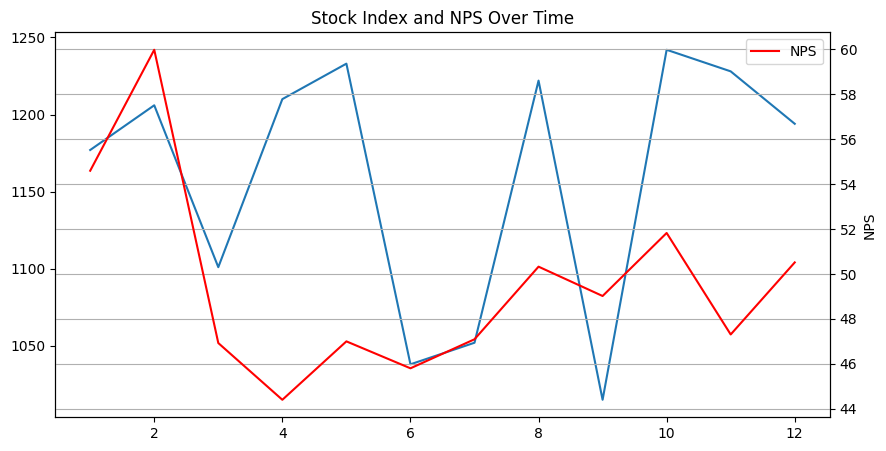

In [171]:
# Convert 'Stock Index' and 'NPS' to numeric, handling potential errors.
stock_nps['Stock Index'] = pd.to_numeric(stock_nps['Stock Index'], errors='coerce')
stock_nps['NPS'] = pd.to_numeric(stock_nps['NPS'], errors='coerce')

# Create a figure and axes for the plot
plt.figure(figsize=(10, 5))

# Plot 'Stock Index'
plt.plot(stock_nps.index, stock_nps['Stock Index'], label='Stock Index')

# Create a secondary y-axis for 'NPS'
ax2 = plt.twinx()
ax2.plot(stock_nps.index, stock_nps['NPS'], color='red', label='NPS')

# Set labels and title
plt.xlabel('Time Period')
plt.ylabel('Stock Index')
ax2.set_ylabel('NPS')
plt.title('Stock Index and NPS Over Time')
plt.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True)
plt.show()

#### Comparison of NPS and Stock Index / 20

- **Divergence**: There are instances where the two lines diverge, indicating that changes in customer sentiment (NPS) do not always align with market performance (Stock Index). For example, a drop in NPS may not coincide with a drop in the stock index, suggesting that customer satisfaction and market performance can be influenced by different factors.
- **Potential Correlation**: In some periods, both metrics may rise or fall together, indicating a potential relationship where improved customer satisfaction could lead to better market performance, or vice versa.

Further analysis could explore specific events or trends that correlate with changes in both metrics to gain deeper insights.

### Merging and Feature Engineering with Media data

In [172]:
media_dat.head()

1,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
1,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.0
2,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.0
3,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.0
4,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.0,0.0
5,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.0,0.0


In [173]:
# Merge media_dat and stock_nps using a common index to merge on
invest_stock_nps = pd.merge(media_dat, stock_nps, left_index=True, right_index=True, how='inner')
invest_stock_nps.head()

,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index
1,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.0,54.599588,1177
2,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.0,59.987101,1206
3,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.0,46.925419,1101
4,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.0,0.0,44.398389,1210
5,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.0,0.0,47.000000,1233


In [174]:
# Create a new DataFrame with GMV sum for each month
# Convert 'order_date' to datetime if it's not already
cust_orders['order_date'] = pd.to_datetime(cust_orders['order_date'])
monthly_gmv_df = cust_orders.groupby(cust_orders['order_date'].dt.month)['gmv'].sum().reset_index()
monthly_gmv_df.index = monthly_gmv_df.index + 1  # Start index from 1
monthly_gmv_df = monthly_gmv_df.rename(columns={'order_date': 'Month', 'gmv': 'monthly_gmv_sum'})
monthly_gmv_df.head()

,Month,monthly_gmv_sum
1,1,2.737371e+08
2,2,2.357855e+08
3,3,2.952506e+08
4,4,2.135047e+08
5,5,3.614201e+08


In [175]:
# Merge with invest_stock_nps
inv_stk_nps_gmv = pd.merge(invest_stock_nps, monthly_gmv_df, on='Month', how='inner')
inv_stk_nps_gmv.index += 1

# Make a new ROI column
inv_stk_nps_gmv['ROI'] = (inv_stk_nps_gmv['monthly_gmv_sum'] / 1e7 - inv_stk_nps_gmv['Total Investment']) * 100 / inv_stk_nps_gmv['Total Investment']
inv_stk_nps_gmv.head()

,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index,monthly_gmv_sum,ROI
1,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.0,54.599588,1177,1.474386e+08,-13.585407
2,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.0,59.987101,1206,2.015590e+05,-99.602001
3,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.0,46.925419,1101,1.774255e+08,-81.567023
4,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.0,0.0,44.398389,1210,3.586634e+08,-78.921531
5,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.0,0.0,47.000000,1233,2.518536e+08,-50.825423


### Merging and refining Customer data

In [176]:
# Join cust_orders and sku_det based on their fsn_id
cust_orders = pd.merge(cust_orders, sku_det, on='fsn_id', how='inner')
cust_orders.head()

,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,cust_id,pincode,product_mrp,product_procurement_sla,list_price,product_analytic_super_category,product_analytic_category,product_analytic_sub_category,product_analytic_vertical
0,ACCDVZ83VBHCWFFA,2023-05-19 13:42:09,146499482.0,188485029.0,3149.0,1,0,0,COD,6.0,-6.148503e+18,-3.21775258155408E+018,6990,4,3149.0,CE,EntertainmentSmall,HomeAudio,HomeAudioSpeaker
1,VGLE4VR7XSQKYFG7,2023-06-11 18:21:50,155827856.0,198823138.0,275.0,1,0,0,COD,8.0,1.585832e+18,-3.70342091330123E+017,600,2,275.0,CE,EntertainmentSmall,TVVideoSmall,VideoGlasses
2,ACCE6VGHYKYFX4WB,2023-06-24 10:20:16,161931009.0,205976637.0,188.0,1,0,0,COD,8.0,-4.882079e+18,2.04427084691886E+018,310,-1,188.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker
3,ACCE2V5DUDZVGFRK,2023-06-25 16:28:12,163016530.0,207267972.0,250.0,1,0,0,COD,7.0,-4.272613e+18,6.14822284391839E+018,400,4,250.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker
4,ACCDFZEJ6ZGSWRMK,2023-06-26 17:02:01,163400507.0,207701702.0,1119.0,1,0,0,COD,28.0,-7.472222e+18,-9.779010321304E+017,2500,3,1119.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker


In [177]:
# Extract year and month
cust_orders['year'] = cust_orders['order_date'].dt.year
cust_orders['month'] = cust_orders['order_date'].dt.month

# Group by 'product_analytic_category', 'year', and 'month', then sum 'gmv'
gmv_by_category_month = cust_orders.groupby(['product_analytic_category', 'year', 'month'])['gmv'].sum().reset_index()
gmv_by_category_month.head()

,product_analytic_category,year,month,gmv
0,Camera,2023,7,3.865863e+07
1,Camera,2023,8,6.275000e+03
2,Camera,2023,9,5.730376e+07
3,Camera,2023,10,1.645322e+08
4,Camera,2023,11,1.268086e+08


### Feature Engineering on Product Type
It can be Luxury type for greater than 80 percentile, else it is Mass-Market

In [178]:
# Calculate the 80th percentile of GMV
gmv_80_percentile = cust_orders['gmv'].quantile(0.8)

# Create a new column 'product_type' based on GMV
cust_orders['product_type'] = 'Mass Market'
cust_orders.loc[cust_orders['gmv'] > gmv_80_percentile, 'product_type'] = 'Luxury'
cust_orders.head()

,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,...,product_mrp,product_procurement_sla,list_price,product_analytic_super_category,product_analytic_category,product_analytic_sub_category,product_analytic_vertical,year,month,product_type
0,ACCDVZ83VBHCWFFA,2023-05-19 13:42:09,146499482.0,188485029.0,3149.0,1,0,0,COD,6.0,...,6990,4,3149.0,CE,EntertainmentSmall,HomeAudio,HomeAudioSpeaker,2023,5,Luxury
1,VGLE4VR7XSQKYFG7,2023-06-11 18:21:50,155827856.0,198823138.0,275.0,1,0,0,COD,8.0,...,600,2,275.0,CE,EntertainmentSmall,TVVideoSmall,VideoGlasses,2023,6,Mass Market
2,ACCE6VGHYKYFX4WB,2023-06-24 10:20:16,161931009.0,205976637.0,188.0,1,0,0,COD,8.0,...,310,-1,188.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker,2023,6,Mass Market
3,ACCE2V5DUDZVGFRK,2023-06-25 16:28:12,163016530.0,207267972.0,250.0,1,0,0,COD,7.0,...,400,4,250.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker,2023,6,Mass Market
4,ACCDFZEJ6ZGSWRMK,2023-06-26 17:02:01,163400507.0,207701702.0,1119.0,1,0,0,COD,28.0,...,2500,3,1119.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker,2023,6,Mass Market


### Customer Acquisition Cost (CAC)

In [179]:
# Unique customers by their cust_id
unique_cust_ids = cust_orders['cust_id'].unique()
unique_cust_ids.shape

(948219,)

In [180]:
# Create a 'year_month' column for easier grouping
cust_orders['year_month'] = cust_orders['order_date'].dt.to_period('M')

# Find new customers for each month
new_customers_by_month = {}
all_new_customers = set()

for year_month, group in cust_orders.groupby('year_month'):
    new_customers = set(group['cust_id']) - all_new_customers
    new_customers_by_month[year_month] = list(new_customers)
    all_new_customers.update(new_customers)

# Create a DataFrame for the results
new_customer_data = []
for year_month, customers in new_customers_by_month.items():
  new_customer_data.append([year_month.year, year_month.month, len(customers)])

new_customer_df = pd.DataFrame(new_customer_data, columns=['Year', 'Month', 'New Customers'])
print(new_customer_df)
print(f"Total number of new customers across all months: {new_customer_df['New Customers'].sum()}")

    Year  Month  New Customers
0   2023      5              1
1   2023      6              6
2   2023      7          66571
3   2023      8            110
4   2023      9          77640
5   2023     10         130719
6   2023     11          79506
7   2023     12          86186
8   2024      1          82576
9   2024      2          82169
10  2024      3          87064
11  2024      4          62980
12  2024      5         108048
13  2024      6          84255
14  2024      7            388
Total number of new customers across all months: 948219


In [181]:
# Delete rows 0, 1, and 14
rows_to_delete = [0, 1, 14]
new_customer_df = new_customer_df.drop(index=rows_to_delete)

# Reset the index and increase it by 1
new_customer_df = new_customer_df.reset_index(drop=True)
new_customer_df.index = new_customer_df.index + 1

new_customer_df.head()

,Year,Month,New Customers
1,2023,7,66571
2,2023,8,110
3,2023,9,77640
4,2023,10,130719
5,2023,11,79506


In [182]:
inv_stk_nps_gmv.head()

,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index,monthly_gmv_sum,ROI
1,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.0,54.599588,1177,1.474386e+08,-13.585407
2,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.0,59.987101,1206,2.015590e+05,-99.602001
3,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.0,46.925419,1101,1.774255e+08,-81.567023
4,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.0,0.0,44.398389,1210,3.586634e+08,-78.921531
5,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.0,0.0,47.000000,1233,2.518536e+08,-50.825423



We will demonstrate how to merge two dataframes and calculate the Customer Acquisition Cost (CAC). The CAC is calculated using the formula:

$$ \text{CAC} = \frac{\text{Total Spend}}{\text{Number of New Customers}} $$

In [183]:
# Merge the two dataframes
cac_df = pd.merge(inv_stk_nps_gmv, new_customer_df, on=['Year', 'Month'], how='inner')

# Calculate CAC
cac_df['CAC'] = cac_df['Total Investment'] / cac_df['New Customers']
cac_df

,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index,monthly_gmv_sum,ROI,New Customers,CAC
0,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.00,0.000000,54.599588,1177,1.474386e+08,-13.585407,66571,0.000256
1,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.00,0.000000,59.987101,1206,2.015590e+05,-99.602001,110,0.046039
2,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.00,0.000000,46.925419,1101,1.774255e+08,-81.567023,77640,0.001240
3,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.00,0.000000,44.398389,1210,3.586634e+08,-78.921531,130719,0.001302
4,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.00,0.000000,47.000000,1233,2.518536e+08,-50.825423,79506,0.000644
5,2023,12,106.745312,5.397502,3.063360,56.705419,1.067307,22.503756,6.826938,11.181030,0.00,0.000000,45.800000,1038,2.928578e+08,-72.564805,86186,0.001239
6,2024,1,74.196000,4.380000,0.456000,4.200000,0.900000,22.900000,7.370000,4.200000,2.70,27.090000,47.093031,1052,2.737371e+08,-63.106216,82576,0.000899
7,2024,2,48.052000,2.586008,1.912651,11.725555,0.596771,19.892366,6.465019,4.873630,0.00,0.000000,50.327406,1222,2.357855e+08,-50.931174,82169,0.000585
8,2024,3,100.024621,9.300000,2.100000,41.590000,0.370000,18.437818,6.217667,5.193591,0.87,15.945545,49.020550,1015,2.952506e+08,-70.482208,87064,0.001149
9,2024,4,56.848241,5.205196,0.871892,24.308354,0.034876,16.514510,5.693456,4.219958,0.00,0.000000,51.827605,1242,2.135047e+08,-62.443041,62980,0.000903


## Exploratory Data Analysis on Sales

### Discounts and Sale days

Following are the special sale days, and pay days are 1st and 15th of every month.

| 2023         | 2024         |
|--------------|--------------|
| 18-19 July   | 20-22 Jan    |
| 15-17 Aug    | 1-2 Feb      |
| 28-30 Aug    | 20-21 Feb    |
| 17-15 Oct    | 14-15 Feb    |
| 7-14 Nov     | 7-9 Mar      |
|              | 25-27 May    |

In [184]:
# Make a discount column in cust_orders
cust_orders['discount'] = 100 * (cust_orders['product_mrp'] - cust_orders['list_price']) / cust_orders['product_mrp']

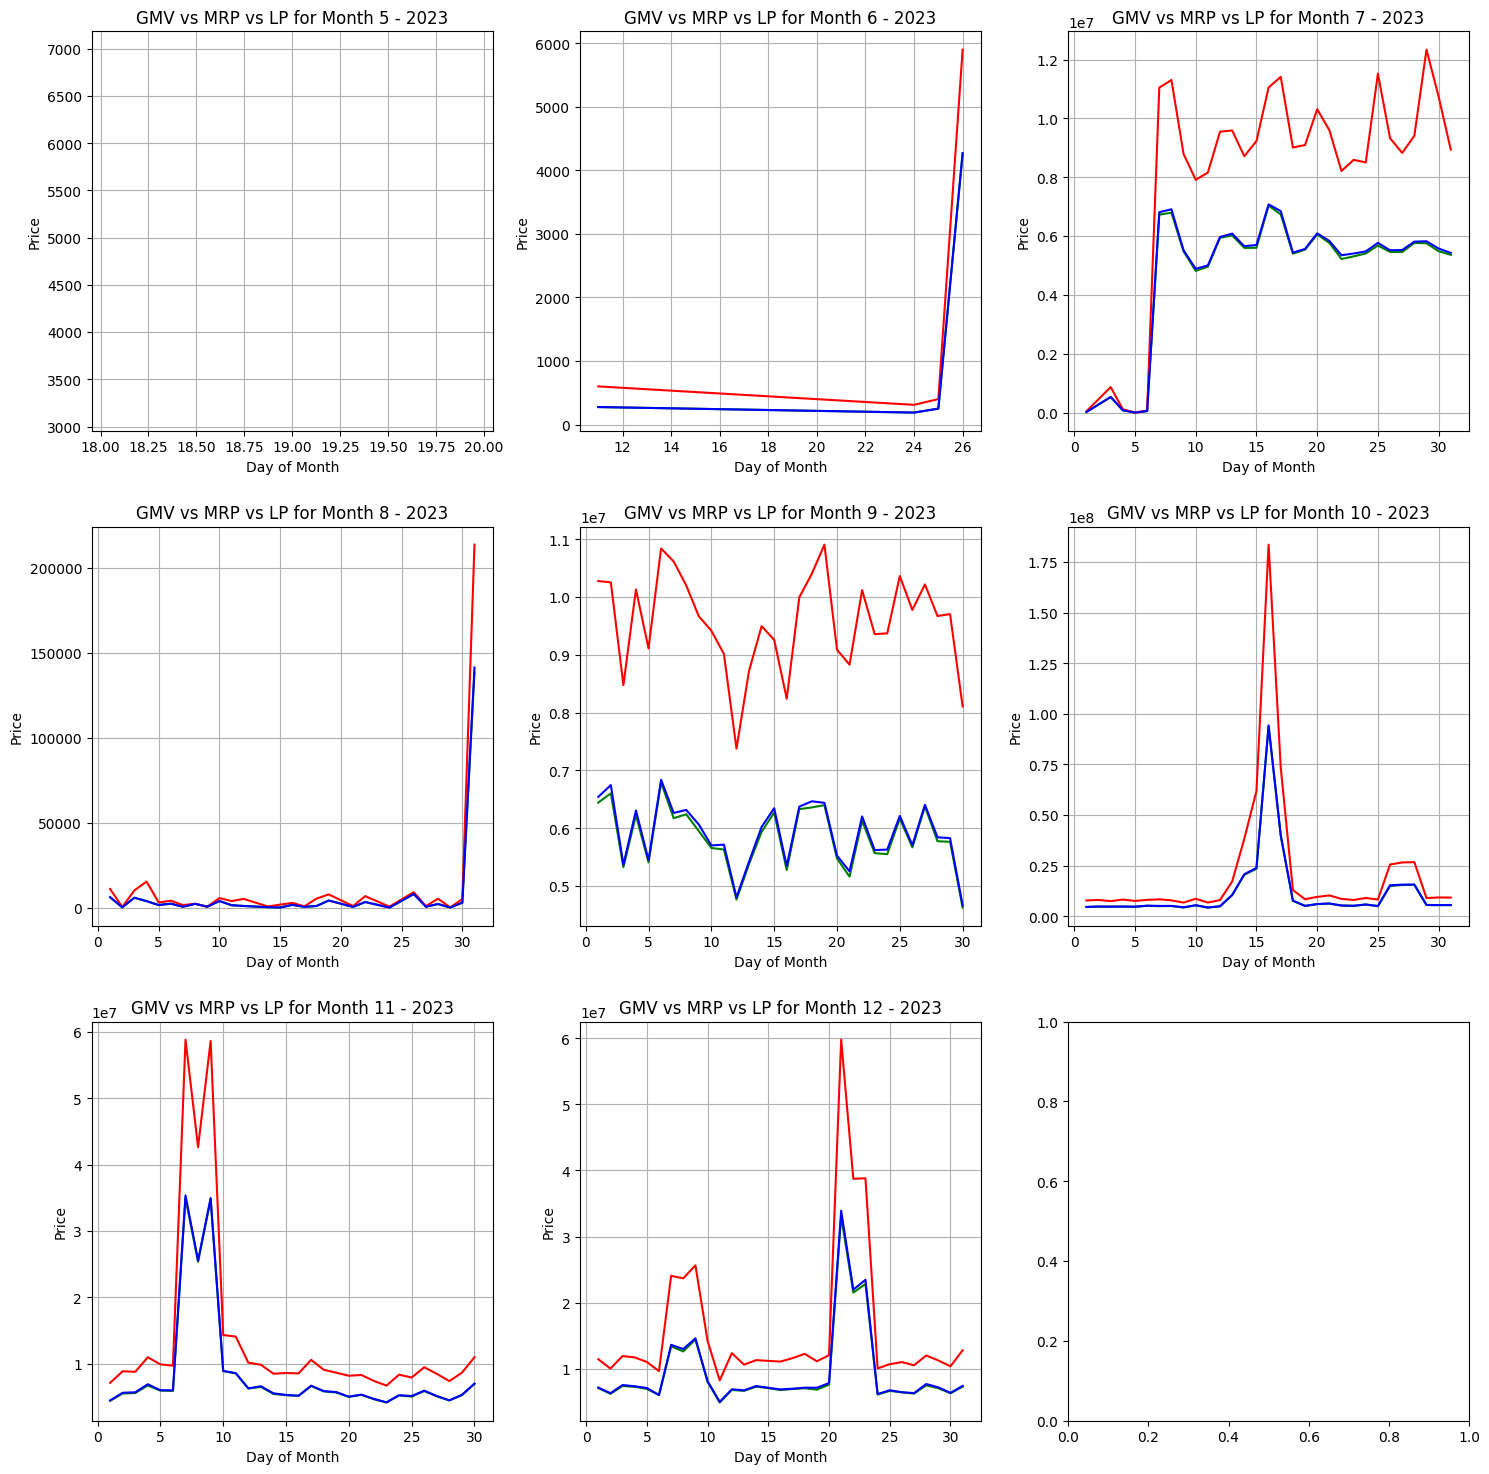

In [185]:
# Plot gmv in year 2023 for each each month

# Convert 'order_date' to datetime objects and filter
cust_orders['order_date'] = pd.to_datetime(cust_orders['order_date'])
cust_orders_2023 = cust_orders[cust_orders['order_date'].dt.year == 2023]

# Group data by month and calculate total GMV for each month
monthly_gmv = cust_orders_2023.groupby(cust_orders_2023['order_date'].dt.month)['gmv'].sum()

# Create subplots for each month
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, month in enumerate(monthly_gmv.index):
    monthly_data = cust_orders_2023[cust_orders_2023['order_date'].dt.month == month]
    daily_gmv = monthly_data.groupby(monthly_data['order_date'].dt.day)['gmv'].sum()
    daily_mrp = monthly_data.groupby(monthly_data['order_date'].dt.day)['product_mrp'].sum()
    daily_lp = monthly_data.groupby(monthly_data['order_date'].dt.day)['list_price'].sum()

    axes[i].plot(daily_lp.index, daily_lp.values, 'g') # Using green for list price
    axes[i].plot(daily_mrp.index, daily_mrp.values, 'r') # Using red for product MRP
    axes[i].plot(daily_gmv.index, daily_gmv.values, 'b') # Using blue for gmv
    axes[i].set_title(f"GMV vs MRP vs LP for Month {month} - 2023")
    axes[i].set_xlabel("Day of Month")
    axes[i].set_ylabel("Price")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

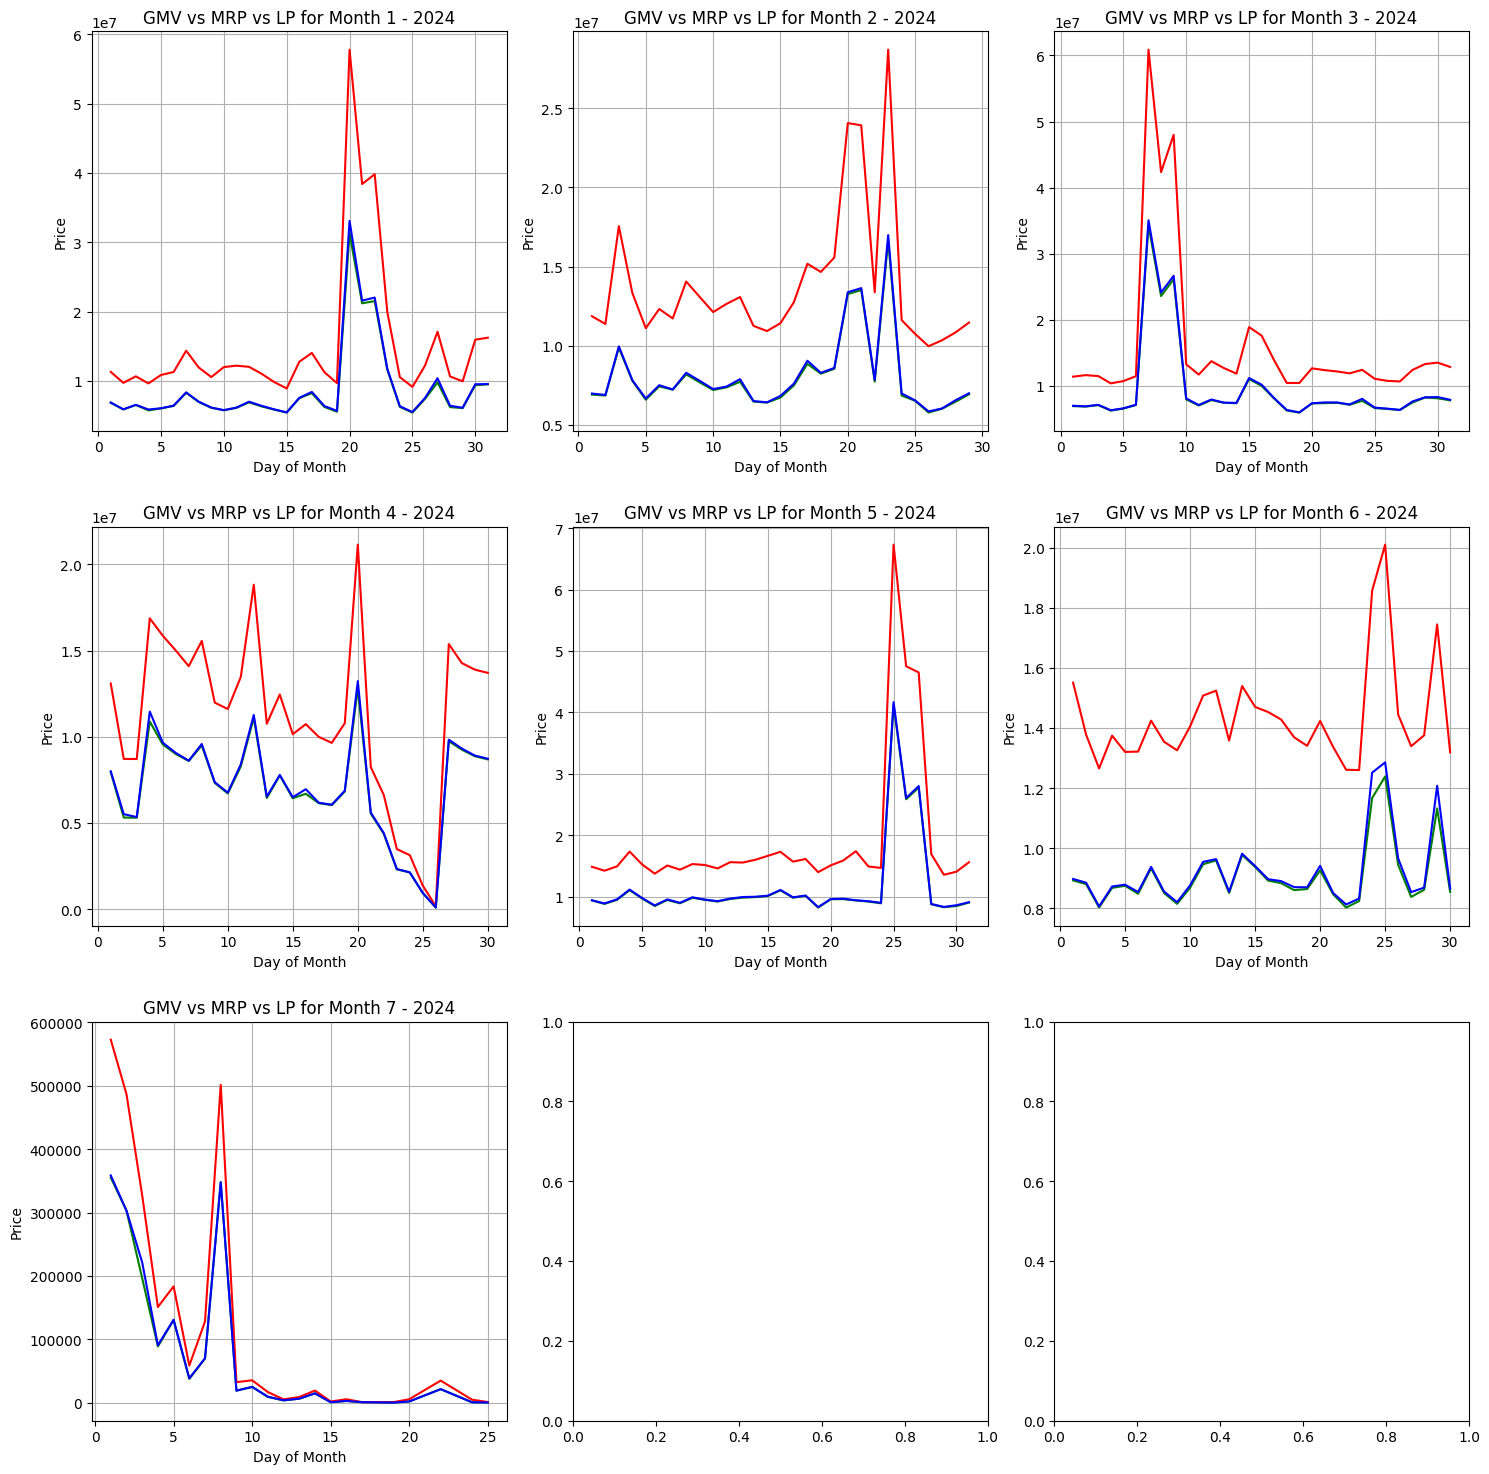

In [186]:
# Plot gmv in year 2024 for each each month

# Convert 'order_date' to datetime objects and filter
cust_orders['order_date'] = pd.to_datetime(cust_orders['order_date'])
cust_orders_2024 = cust_orders[cust_orders['order_date'].dt.year == 2024]

# Group data by month and calculate total GMV for each month
monthly_gmv = cust_orders_2024.groupby(cust_orders_2024['order_date'].dt.month)['gmv'].sum()

# Create subplots for each month
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, month in enumerate(monthly_gmv.index):
    monthly_data = cust_orders_2024[cust_orders_2024['order_date'].dt.month == month]
    daily_gmv = monthly_data.groupby(monthly_data['order_date'].dt.day)['gmv'].sum()
    daily_mrp = monthly_data.groupby(monthly_data['order_date'].dt.day)['product_mrp'].sum()
    daily_lp = monthly_data.groupby(monthly_data['order_date'].dt.day)['list_price'].sum()

    axes[i].plot(daily_lp.index, daily_lp.values, 'g') # Using green for list price
    axes[i].plot(daily_mrp.index, daily_mrp.values, 'r') # Using red for product MRP
    axes[i].plot(daily_gmv.index, daily_gmv.values, 'b') # Using blue for gmv
    axes[i].set_title(f"GMV vs MRP vs LP for Month {month} - 2024")
    axes[i].set_xlabel("Day of Month")
    axes[i].set_ylabel("Price")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### How Discounts are Driving Revenue?

Based on the provided GMV graphs for each month in 2023-24, we can draw several conclusions about the impact of discounts on revenue:

1. **Sales Peaks During Discount Periods**:
   - The graphs show noticeable spikes in GMV during specific sales days, particularly around the sales periods outlined in the sales calendar. This suggests that discounts are effectively driving higher sales volumes during these times.

2. **Increased Customer Engagement**:
   - The presence of discounts likely attracts more customers, leading to increased traffic and sales. The spikes in GMV indicate that customers are responding positively to promotional pricing.

3. **Revenue Generation**:
   - The overall revenue generated during discount periods appears to be higher than during non-discount periods. This is evident from the spikes in GMV, which indicate that the revenue generated during these times outweighs the potential loss from offering discounts.


#### Conclusion: Are Holidays or Paydays Impacting Sales?

Holidays significantly impact sales, as retailers often implement price hikes during peak shopping times, capitalizing on consumers' willingness to spend more. Events like Labour Day, Thanksgiving, Halloween, Christmas, Canada Day and other holidays drive increased consumer spending, leading to higher prices for goods and services. Consumers are more inclined to make purchases during these festive occasions, prioritizing holiday-related spending around these events. In contrast, paydays do not show a significant influence on sales patterns, indicating that holiday promotions and consumer behavior around these times are more impactful.

### Customer satisfaction(NPS) and sales


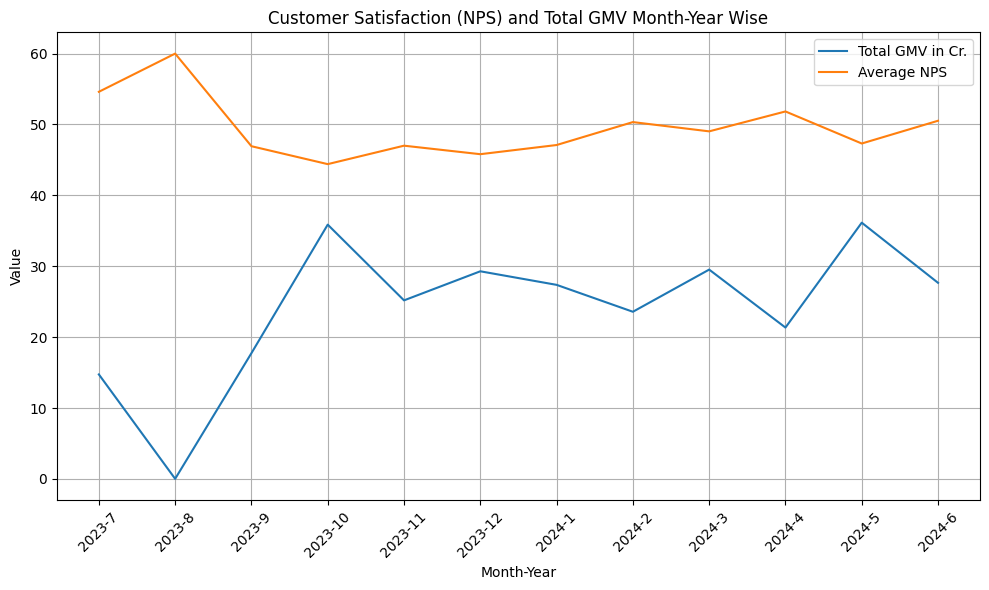

In [187]:
# prompt: plot Customer satisfaction(NPS) and total gmv month-year wise

import matplotlib.pyplot as plt

# Assuming you have a DataFrame named 'cust_orders' with columns 'order_date', 'gmv', and 'nps'
# And you have already extracted 'year' and 'month' from 'order_date'
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(inv_stk_nps_gmv['Year'].astype(str) + '-' + inv_stk_nps_gmv['Month'].astype(str),
         inv_stk_nps_gmv['monthly_gmv_sum']/1e7, label='Total GMV in Cr.')
plt.plot(inv_stk_nps_gmv['Year'].astype(str) + '-' + inv_stk_nps_gmv['Month'].astype(str),
         inv_stk_nps_gmv['NPS'], label='Average NPS')

plt.xlabel('Month-Year')
plt.ylabel('Value')
plt.title('Customer Satisfaction (NPS) and Total GMV Month-Year Wise')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Observations from the Graph:

1. **NPS Stability vs. GMV Fluctuations:**
 - The NPS line (orange) appears relatively stable, while the GMV line (blue) shows more pronounced fluctuations. This suggests that changes in GMV might not immediately reflect changes in NPS.

2. **Potential Lagged Relationship:**

 - There are periods where an increase in NPS is followed by an increase in GMV in subsequent months, this could indicate a lag effect. For example, a rise in NPS in one month might lead to increased GMV in the following months as customer satisfaction translates into repeat purchases or positive word-of-mouth.

### COD vs prepaid share of products

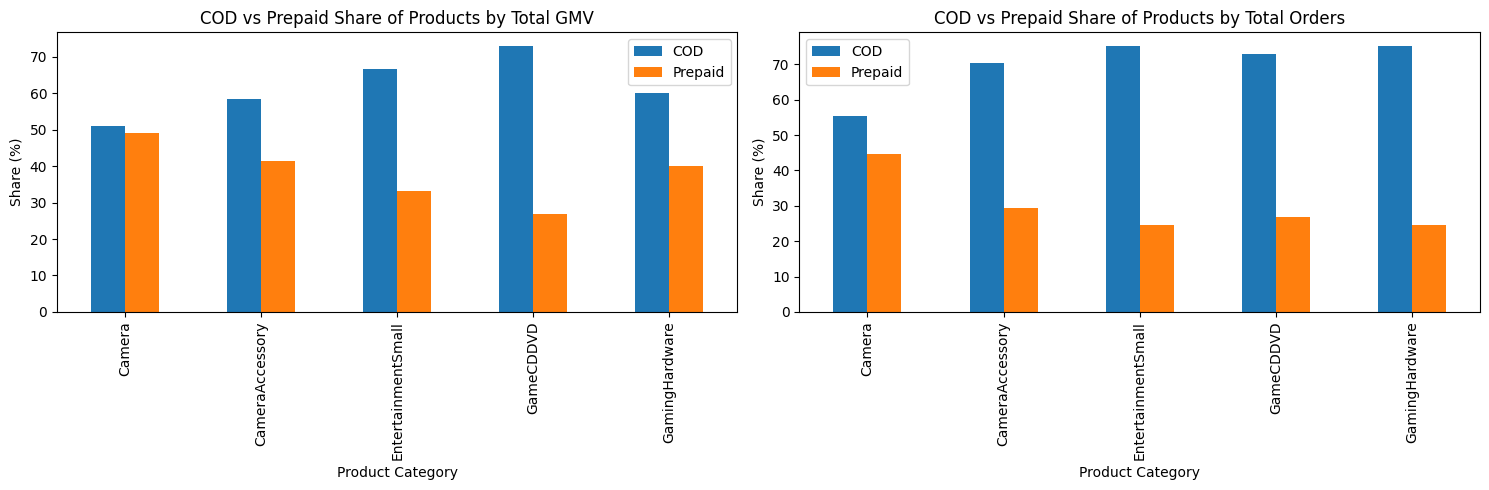

In [188]:
# Group by product category and payment type, then count orders
cod_vs_prepaid_by_product = cust_orders.groupby(['product_analytic_category', 'order_payment_type'])['order_id'].count().unstack()

# Calculate the total orders for each product category
cod_vs_prepaid_by_product['Total Orders'] = cod_vs_prepaid_by_product['COD'] + cod_vs_prepaid_by_product['Prepaid']

# Calculate the COD share and Prepaid share
cod_vs_prepaid_by_product['COD Share (%)'] = (cod_vs_prepaid_by_product['COD'] / cod_vs_prepaid_by_product['Total Orders']) * 100
cod_vs_prepaid_by_product['Prepaid Share (%)'] = (cod_vs_prepaid_by_product['Prepaid'] / cod_vs_prepaid_by_product['Total Orders']) * 100

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot 1: COD vs Prepaid share by GMV
gmv_by_product_payment = cust_orders.groupby(['product_analytic_category', 'order_payment_type'])['gmv'].sum().unstack()
gmv_by_product_payment['Total GMV'] = gmv_by_product_payment['COD'] + gmv_by_product_payment['Prepaid']
gmv_by_product_payment['COD Share (%)'] = (gmv_by_product_payment['COD'] / gmv_by_product_payment['Total GMV']) * 100
gmv_by_product_payment['Prepaid Share (%)'] = (gmv_by_product_payment['Prepaid'] / gmv_by_product_payment['Total GMV']) * 100

ax1 = gmv_by_product_payment[['COD Share (%)', 'Prepaid Share (%)']].plot(kind='bar', ax=axes[0], rot=90)
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Share (%)')
ax1.set_title('COD vs Prepaid Share of Products by Total GMV')
ax1.legend(['COD', 'Prepaid'])


# Plot 2: COD vs Prepaid share by Orders
ax2 = cod_vs_prepaid_by_product[['COD Share (%)', 'Prepaid Share (%)']].plot(kind='bar', ax=axes[1], rot=90)
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Share (%)')
ax2.set_title('COD vs Prepaid Share of Products by Total Orders')
ax2.legend(['COD', 'Prepaid'])

plt.tight_layout()
plt.show()


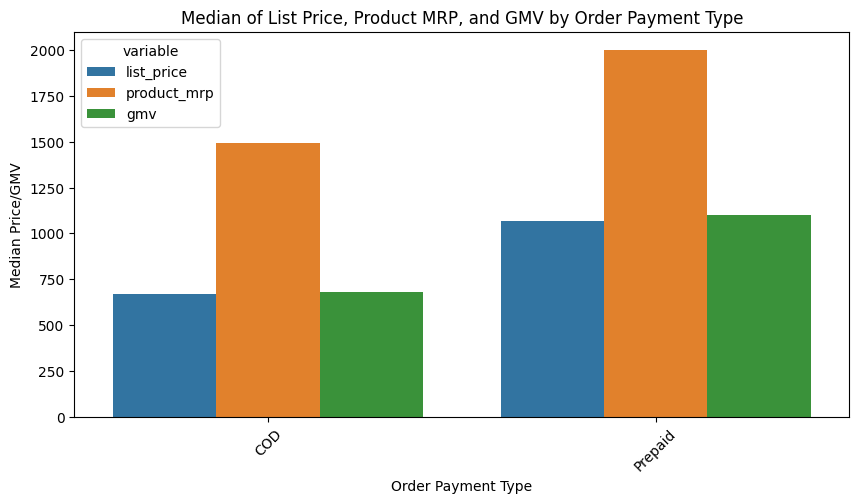

In [189]:
# Convert 'list_price' and 'product_mrp' to numeric
cust_orders['list_price'] = pd.to_numeric(cust_orders['list_price'], errors='coerce')
cust_orders['product_mrp'] = pd.to_numeric(cust_orders['product_mrp'], errors='coerce')
cust_orders['gmv'] = pd.to_numeric(cust_orders['gmv'], errors='coerce')

# Drop rows with NaN values in 'list_price', 'product_mrp' and 'gmv'
cust_orders = cust_orders.dropna(subset=['list_price', 'product_mrp', 'gmv'])

# Calculate the median of 'list_price', 'product_mrp', and 'gmv' for each 'order_payment_type'
median_prices = cust_orders.groupby('order_payment_type').agg(
    {'list_price': 'median', 'product_mrp': 'median', 'gmv': 'median'}
).reset_index()


# Create the plot
plt.figure(figsize=(10, 5))  # Adjust figure size as needed
sns.barplot(x='order_payment_type', y='value', hue='variable',
            data=pd.melt(median_prices, id_vars='order_payment_type',
                        value_vars=['list_price', 'product_mrp', 'gmv']))

plt.title('Median of List Price, Product MRP, and GMV by Order Payment Type')
plt.xlabel('Order Payment Type')
plt.ylabel('Median Price/GMV')
plt.xticks(rotation=45)
plt.show()

#### Observations

   - **COD Preference**: COD has a higher share of GMV and orders across all product categories, indicating customer preference for paying upon delivery.
   - **Prepaid Pricing**: Higher median MRP for Prepaid orders suggests customers are willing to pay more upfront for certain products.

#### Business Improvement Ideas

1. **Enhance Trust for Prepaid**:
   - Offer incentives like discounts or faster delivery for Prepaid orders to encourage more customers to choose this option.
   - Improve trust through clear return policies and customer reviews to make Prepaid more appealing.

2. **Leverage COD Popularity**:
   - Use COD's popularity to upsell or cross-sell products, potentially increasing the average order value.
   - Implement loyalty programs for COD customers to encourage repeat purchases and eventually transition them to Prepaid.

3. **Targeted Promotions**:
   - Design promotions that specifically target high-value Prepaid purchases, leveraging the willingness of these customers to spend more.


### Seasonal Impact on ROI

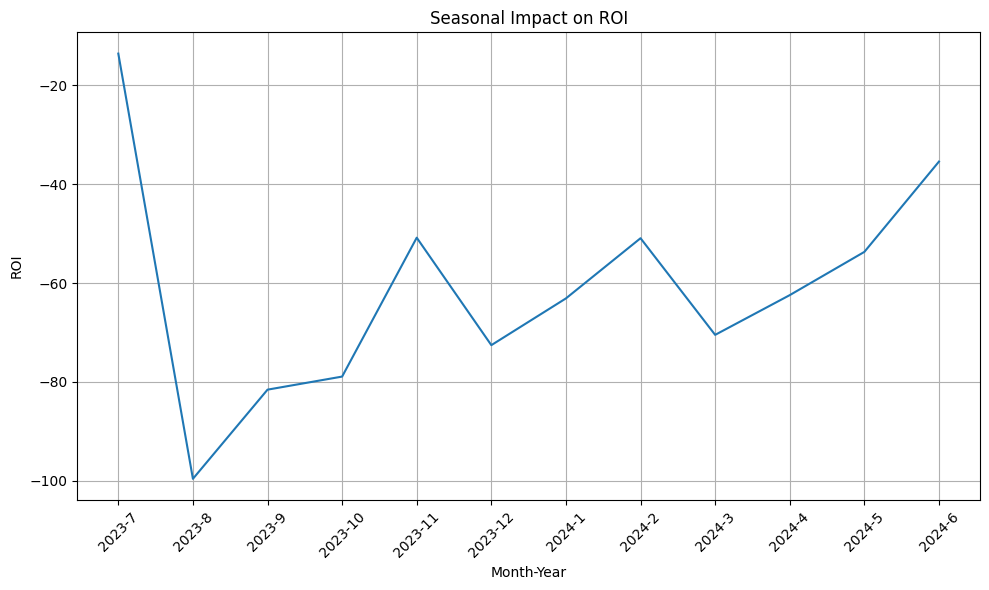

In [190]:
# Create a combined 'Month-Year' column
cac_df['Month-Year'] = cac_df['Year'].astype(str) + '-' + cac_df['Month'].astype(str)

# Plot ROI over time
plt.figure(figsize=(10, 6))
plt.plot(cac_df['Month-Year'], cac_df['ROI'])
plt.xlabel('Month-Year')
plt.ylabel('ROI')
plt.title('Seasonal Impact on ROI')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.show()

#### Observations

- **Fluctuating ROI**: ROI varies significantly, with notable dips, especially mid-2023, indicating seasonal impacts.

#### Improvement Ideas

1. **Adjust Strategies**:
   - **Cost Control**: Focus on reducing costs during low ROI periods.
   - **Promotions**: Boost sales with targeted campaigns during downturns.

2. **Resource Allocation**:
   - **Invest in Peaks**: Increase efforts during high ROI months.
   - **Optimize Off-Peak**: Use quieter times for planning and improvements.


## Exploratory Data Analysis on Products

### BCG Matrix

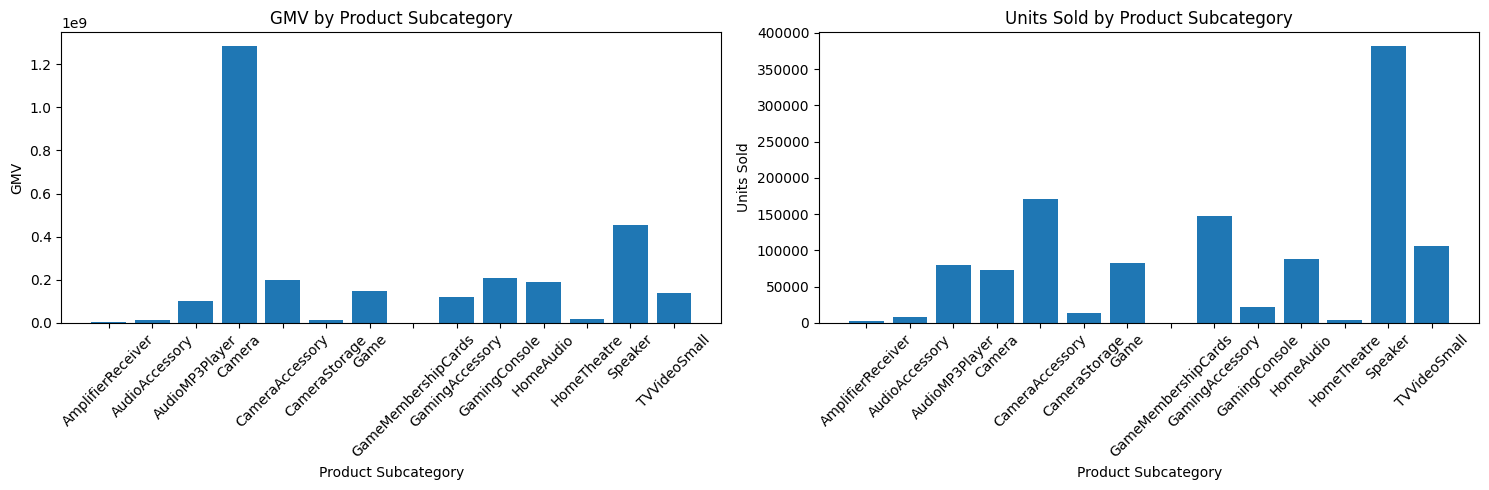

In [191]:
# Group by 'product_analytic_sub_category' and sum 'gmv' and 'units'
gmv_by_subcategory = cust_orders.groupby('product_analytic_sub_category')['gmv'].sum()
units_sold_by_subcategory = cust_orders.groupby('product_analytic_sub_category')['units'].sum()

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot GMV by product subcategory
axes[0].bar(gmv_by_subcategory.index, gmv_by_subcategory.values)
axes[0].set_xlabel('Product Subcategory')
axes[0].set_ylabel('GMV')
axes[0].set_title('GMV by Product Subcategory')
axes[0].tick_params(axis='x', rotation=45)

# Plot Units Sold by product subcategory
axes[1].bar(units_sold_by_subcategory.index, units_sold_by_subcategory.values)
axes[1].set_xlabel('Product Subcategory')
axes[1].set_ylabel('Units Sold')
axes[1].set_title('Units Sold by Product Subcategory')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


1. **High GMV but Moderate Units Sold → High-Value Products (Premium Segment)**
   - **Cameras**:
     - **GMV**: 44%
     - **Units Sold**: Moderate
     - **Takeaway**: Focus on premium positioning, warranties, and professional bundles to leverage high Average Selling Price (ASP).

   - **Gaming Consoles**:
     - **GMV**: 7%
     - **Units Sold**: Low
     - **Takeaway**: Implement financing options or trade-in deals to enhance unit sales.

2. **High Units Sold but Lower GMV → Low-Margin, High-Volume Products**
   - **Speakers**:
     - **GMV**: 15.9%
     - **Units Sold**: Highest
     - **Takeaway**: Improve margins through upselling premium models or bundling accessories.

   - **Gaming Accessories & Game Membership Cards**:
     - **Units Sold**: High, but low GMV share
     - **Takeaway**: Enhance profitability by bundling with consoles or offering subscription models.

3. **Low GMV & Low Units Sold → Underperforming Categories (Potential Dogs)**
   - **Amplifier Receivers, Audio Accessories, Camera Storage, Home Theatre**:
     - **Takeaway**: Consider phasing out or repositioning these products with targeted marketing.

4. **Potential Growth Areas**
   - **Camera Accessories**:
     - **GMV**: Good, High Units Sold
     - **Takeaway**: Leverage bundled promotions with cameras to boost sales.

   - **Gaming Accessories**:
     - **GMV**: Moderate, Units Sold: Moderate
     - **Takeaway**: Launch gaming bundles (console + accessories + games) to increase sales volume.

#### Strategic Recommendations

- **Focus on High-GMV, Premium Products**:
  - Market Cameras and Consoles with premium positioning and financing offers to attract higher-value customers.

- **Improve Margins on High-Volume, Low-GMV Categories**:
  - Utilize bundling, upselling, and premium variants for Speakers and Accessories to enhance profitability.

- **Optimize Marketing for High-Potential Growth Areas**:
  - Push Camera and Gaming Accessories through bundling and influencer marketing to tap into their growth potential.

- **Reevaluate or Phase Out Underperformers**:
  - Strategically reposition or eliminate products like Amplifiers and Camera Storage that are not performing well.


Here's a similar BCG matrix table for GMV and Units Sold:

| Category                  | Market Share (GMV%) | Sales Volume (Units Sold) | BCG Quadrant   |
|---------------------------|---------------------|---------------------------|----------------|
| Camera                    | High (44%)          | Moderate                  | 💰 Cash Cow    |
| Speakers                  | High (15.9%)        | Very High                 | ⭐ Star        |
| Home Audio                | Moderate (6.6%)     | Moderate                  | ❓ Question Mark |
| Gaming Console            | Moderate (7%)       | Low                       | ❓ Question Mark |
| Camera Accessories        | Moderate (7.1%)     | Moderate                  | 💰 Cash Cow    |
| Gaming Accessories        | Moderate (4.2%)     | Moderate                  | ❓ Question Mark |
| Games                     | Moderate (5.3%)     | Moderate                  | ❓ Question Mark |
| Camera Storage            | Low (0.4%)          | Low                       | ❌ Dog         |
| Game Membership Cards     | Low (0.0%)          | Moderate                  | ❌ Dog         |
| TV/Video Small            | Moderate            | Moderate                  | ❓ Question Mark |
| Home Theatre              | Low (0.6%)          | Very Low                  | ❌ Dog         |
| Audio Accessories, Amplifiers | Low              | Low                       | ❌ Dog         |

This table categorizes each product based on its market share and sales volume, placing them into the appropriate BCG quadrant.

### Product MRP distribution plot of each product

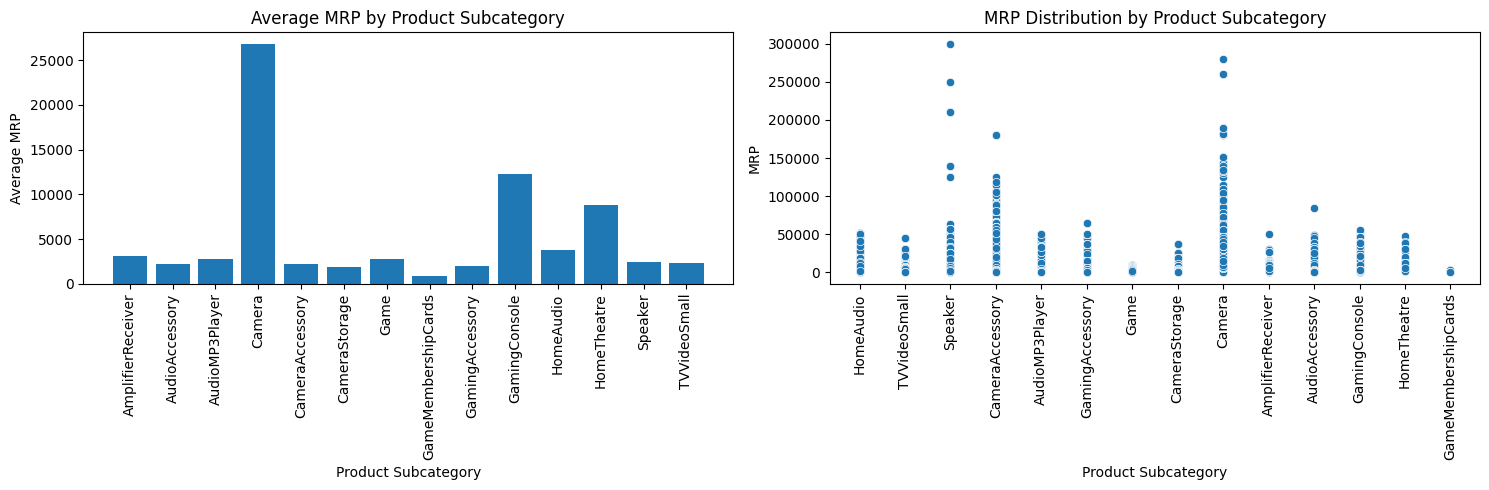

In [192]:
# Group by 'product_analytic_sub_category' and calculate the average MRP
average_mrp_by_subcategory = cust_orders.groupby('product_analytic_sub_category')['product_mrp'].mean()

# Create subplots for side-by-side visualization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot 1: Bar plot of average MRP for each product subcategory
axes[0].bar(average_mrp_by_subcategory.index, average_mrp_by_subcategory.values)
axes[0].set_xlabel('Product Subcategory')
axes[0].set_ylabel('Average MRP')
axes[0].set_title('Average MRP by Product Subcategory')
axes[0].tick_params(axis='x', rotation=90, labelright=True)

# Plot 2: Scatter plot to visualize the distribution of MRP within each subcategory
sns.scatterplot(x='product_analytic_sub_category', y='product_mrp', data=cust_orders, ax=axes[1])
axes[1].set_xlabel('Product Subcategory')
axes[1].set_ylabel('MRP')
axes[1].set_title('MRP Distribution by Product Subcategory')
axes[1].tick_params(axis='x', rotation=90, labelright=True)

plt.tight_layout()
plt.show()

#### Key Insights from MRP Analysis

- **Cameras**: Highest average MRP, indicating a premium product. Focus on high-value sales.

- **Gaming Consoles**: High MRP, supporting premium positioning.

- **Speakers & TV/Video Small**: Lower MRP, suggesting affordability and high-volume sales.

- **Home Audio & Theatre**: Moderate MRP, indicating mid-range pricing.

#### Takeaways

- **Premium Focus**: Market Cameras and Consoles as high-value products.
  
- **Volume Strategy**: Use affordability and bundling for Speakers and TV/Video Small to boost sales.

### Top 3 categories (GMV vs month and Units sold vs month)


In [193]:
# Extract year and month
cust_orders['year'] = cust_orders['order_date'].dt.year
cust_orders['month'] = cust_orders['order_date'].dt.month

# Group by 'product_analytic_category', 'year', and 'month', then sum 'gmv'
gmv_by_category_month = cust_orders.groupby(['product_analytic_category', 'year', 'month'])['gmv'].sum().reset_index()
gmv_by_category_month.head()

,product_analytic_category,year,month,gmv
0,Camera,2023,7,3.865863e+07
1,Camera,2023,8,6.275000e+03
2,Camera,2023,9,5.730376e+07
3,Camera,2023,10,1.645322e+08
4,Camera,2023,11,1.268086e+08


In [194]:
# Group by 'product_analytic_category', 'year', and 'month', then count 'order_id'
noof_orders_by_category_month = cust_orders.groupby(['product_analytic_category', 'year', 'month'])['order_id'].count().reset_index()
noof_orders_by_category_month.head()

,product_analytic_category,year,month,order_id
0,Camera,2023,7,2875
1,Camera,2023,8,1
2,Camera,2023,9,3926
3,Camera,2023,10,10781
4,Camera,2023,11,6889


In [195]:
# Filter data for the specified period (2023-05 to 2024-07)
start_date = pd.to_datetime('2023-05-01')
end_date = pd.to_datetime('2024-07-31')

filtered_data_gmv = gmv_by_category_month[
    (pd.to_datetime(gmv_by_category_month['year'].astype(str) + '-' + gmv_by_category_month['month'].astype(str) + '-01') >= start_date) &
    (pd.to_datetime(gmv_by_category_month['year'].astype(str) + '-' + gmv_by_category_month['month'].astype(str) + '-01') <= end_date)
]

filtered_data_orders = noof_orders_by_category_month[
    (pd.to_datetime(noof_orders_by_category_month['year'].astype(str) + '-' + noof_orders_by_category_month['month'].astype(str) + '-01') >= start_date) &
    (pd.to_datetime(noof_orders_by_category_month['year'].astype(str) + '-' + noof_orders_by_category_month['month'].astype(str) + '-01') <= end_date)
]

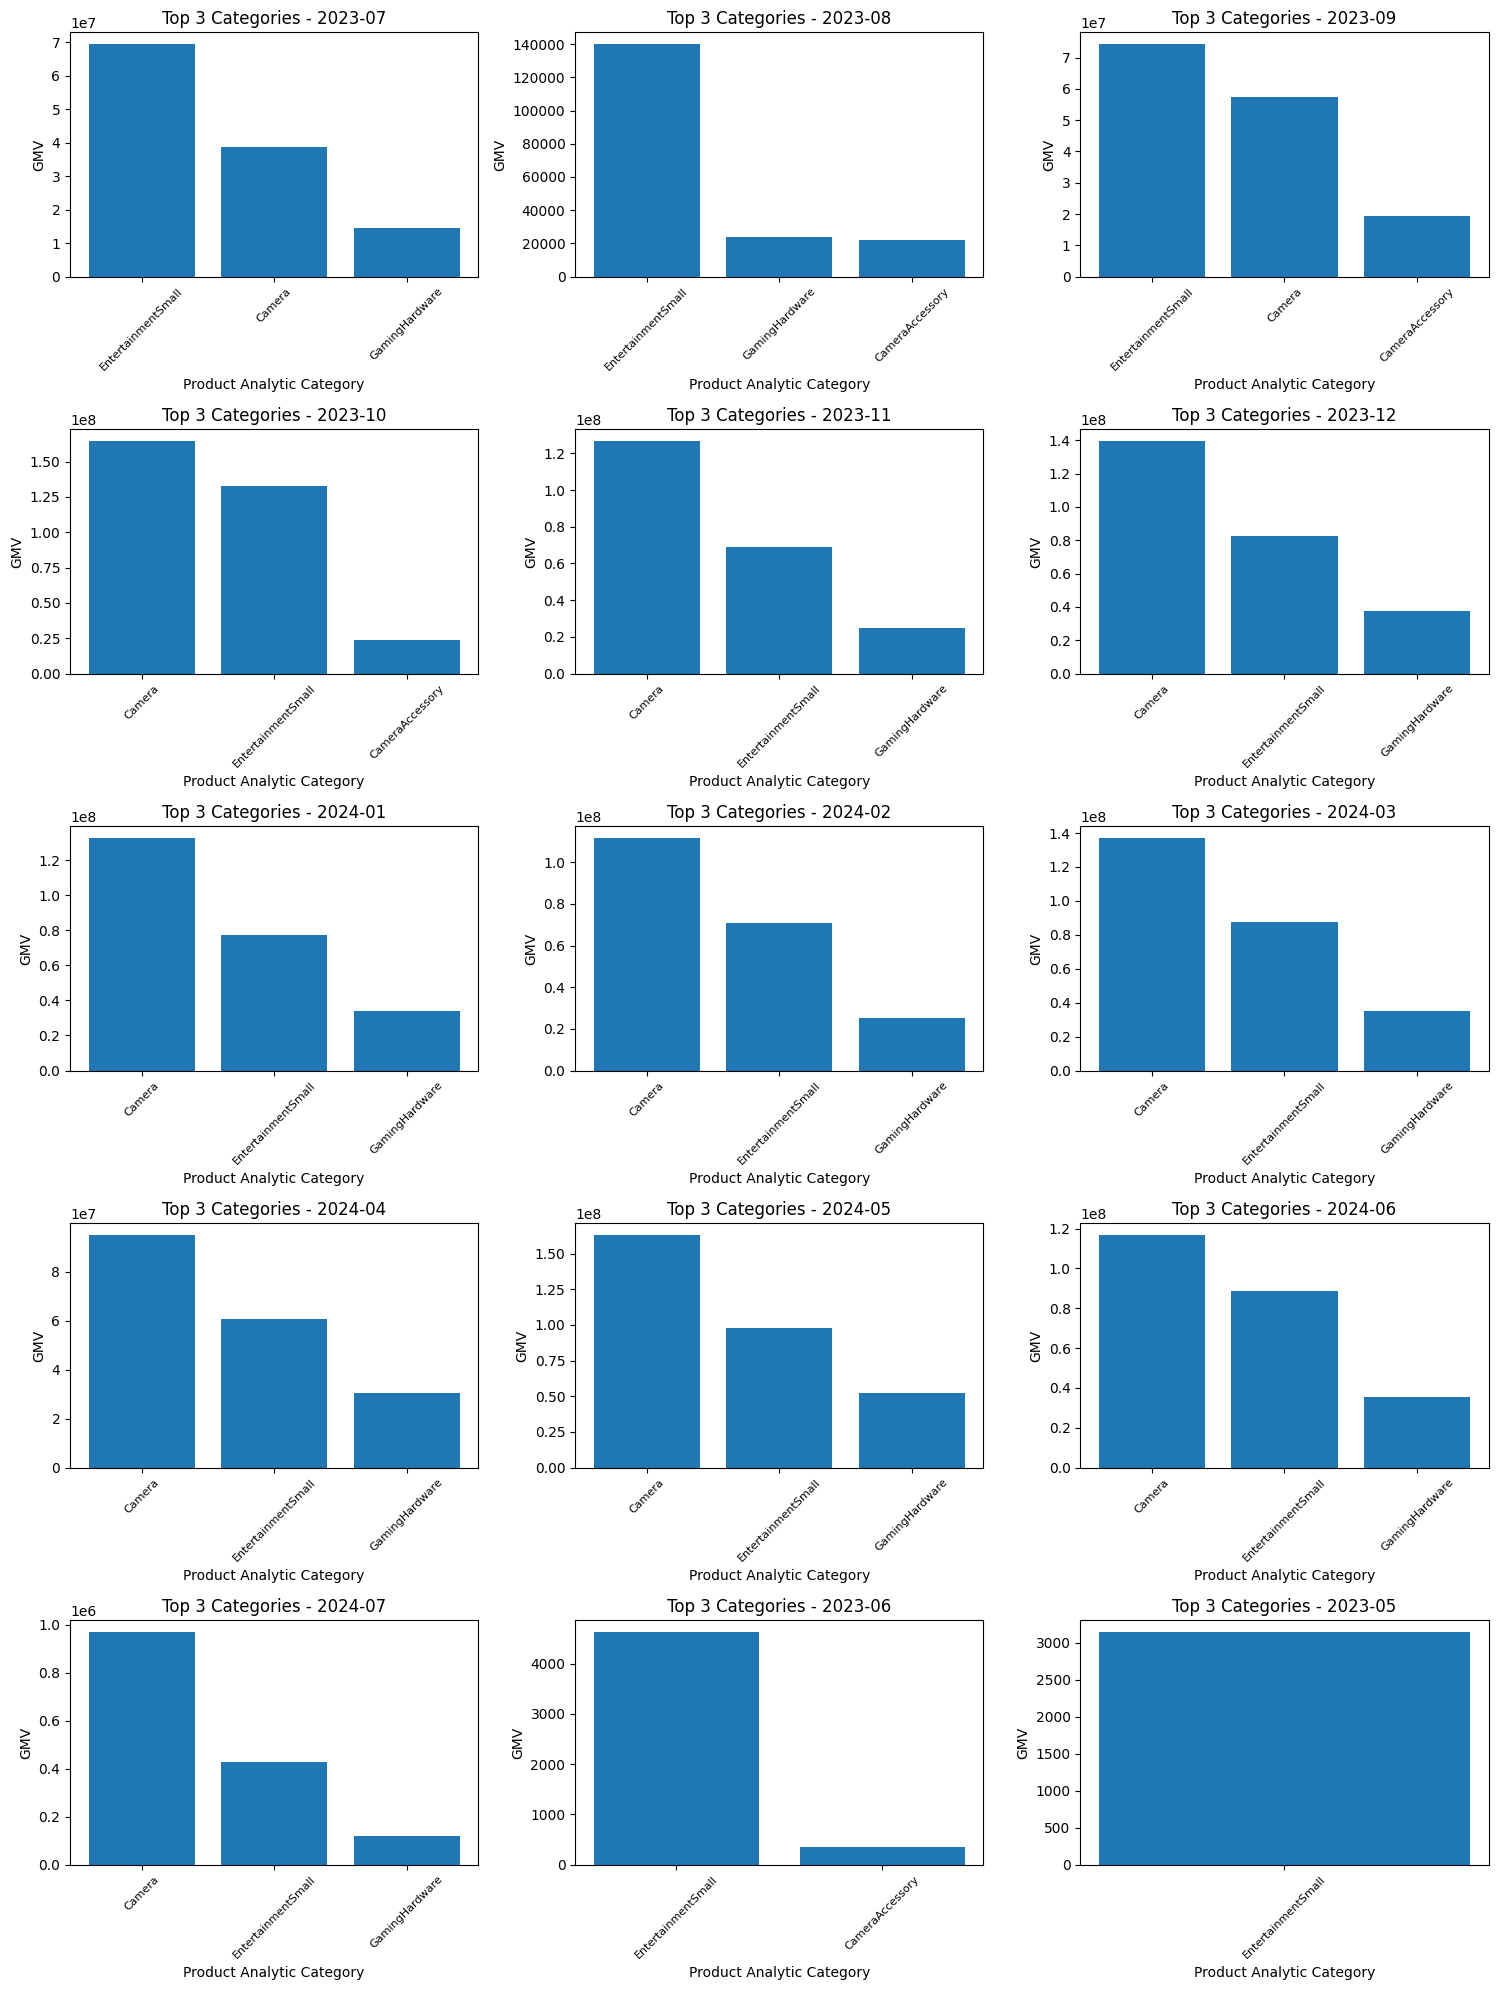

In [196]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

# Iterate through months
for i, (year, month) in enumerate(filtered_data_gmv[['year', 'month']].drop_duplicates().values):
    # Filter data for the current month
    monthly_data = filtered_data_gmv[(filtered_data_gmv['year'] == year) & (filtered_data_gmv['month'] == month)]

    # Get the top 3 categories
    top_3_categories = monthly_data.nlargest(3, 'gmv')['product_analytic_category'].tolist()
    top_3_gmv = monthly_data.nlargest(3, 'gmv')['gmv'].tolist()

    # Create the histogram
    axes[i].bar(top_3_categories, top_3_gmv)
    axes[i].set_title(f'Top 3 Categories - {year}-{month:02}')
    axes[i].set_xlabel('Product Analytic Category')
    axes[i].set_ylabel('GMV')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)  # Adjust label rotation and size
    axes[i].xaxis.set_tick_params(labelsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

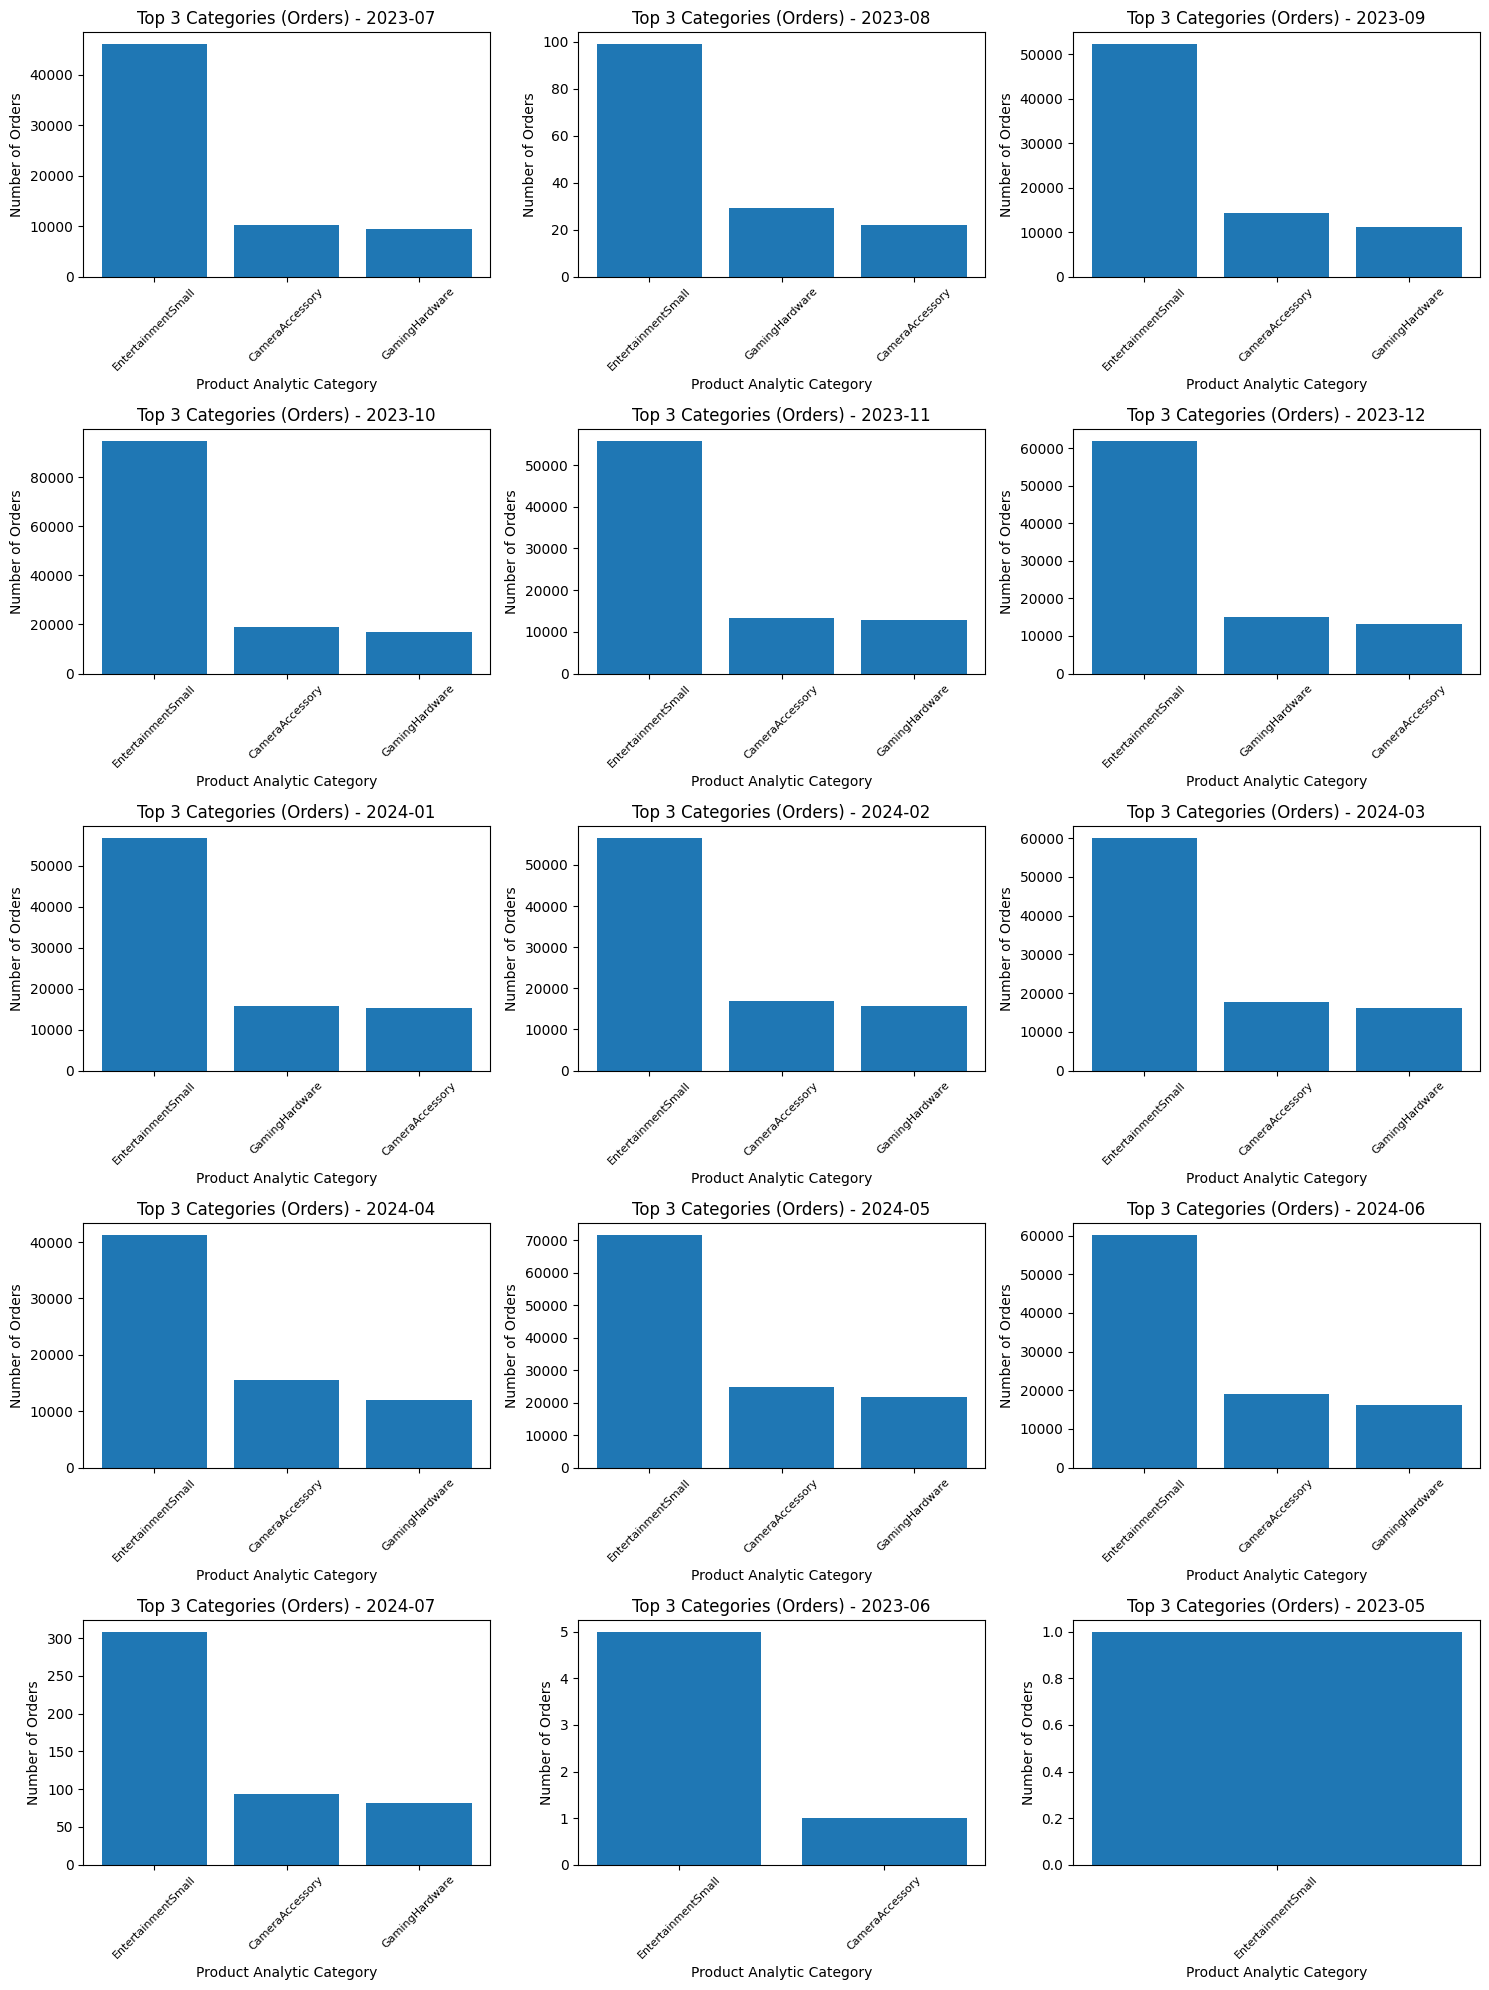

In [197]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

# Iterate through months
for i, (year, month) in enumerate(filtered_data_orders[['year', 'month']].drop_duplicates().values):
    # Filter data for the current month
    monthly_data = filtered_data_orders[(filtered_data_orders['year'] == year) & (filtered_data_orders['month'] == month)]

    # Get the top 3 categories based on order count
    top_3_categories = monthly_data.nlargest(3, 'order_id')['product_analytic_category'].tolist()
    top_3_orders = monthly_data.nlargest(3, 'order_id')['order_id'].tolist()

    # Create the histogram
    axes[i].bar(top_3_categories, top_3_orders)
    axes[i].set_title(f'Top 3 Categories (Orders) - {year}-{month:02}')
    axes[i].set_xlabel('Product Analytic Category')
    axes[i].set_ylabel('Number of Orders')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)  # Adjust label rotation and size
    axes[i].xaxis.set_tick_params(labelsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


#### Business Analysis

1. **Top Performing Categories**:
   - **EntertainmentSmall**: Dominates both orders and GMV consistently, highlighting its strong market demand.
   - **Camera and CameraAccessory**: Regularly feature in the top three, indicating steady consumer interest.

2. **Monthly Patterns**:
   - **Seasonal Peaks**: Significant increases in orders and GMV during certain months, likely due to holiday seasons or special promotions.
   - **Stable Categories**: Consistent performance in some categories suggests a reliable customer base.

#### Strategic Recommendations

1. **Maximize EntertainmentSmall Potential**:
   - **Stock Management**: Ensure adequate inventory to meet high demand, especially during peak months.
   - **Targeted Marketing**: Develop campaigns focused on EntertainmentSmall to further boost sales.

2. **Boost Camera and Accessory Sales**:
   - **Bundle Offers**: Create attractive bundles with Camera and CameraAccessory to increase purchase value.
   - **Cross-Selling**: Implement cross-selling strategies with related products to enhance market penetration.


## Exploratory Data Analysis on Marketing Investment

### Ad spend by month

In [198]:
# Create a 'Date' column using Year and Month
cac_df["Date"] = pd.to_datetime(cac_df[["Year", "Month"]].assign(Day=1))

# Sort by Date to ensure chronological order
media_df = cac_df.sort_values(by="Date")

# Print the updated DataFrame
print(media_df[["Year", "Month", "Date"]].head())

   Year  Month       Date
0  2023      7 2023-07-01
1  2023      8 2023-08-01
2  2023      9 2023-09-01
3  2023     10 2023-10-01
4  2023     11 2023-11-01


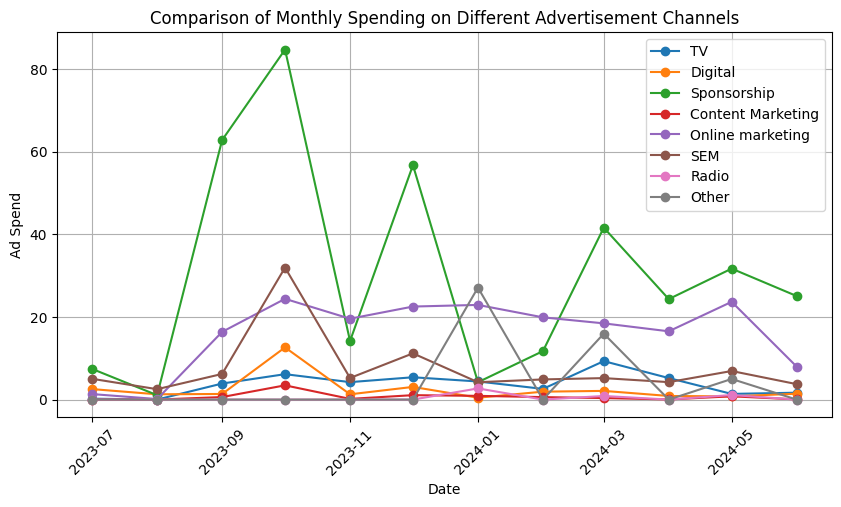

In [199]:
# List of media categories to plot
media_categories = ["TV", "Digital", "Sponsorship", "Content Marketing", "Online marketing", "SEM", "Radio", "Other"]

# Create a single figure
plt.figure(figsize=(10, 5))

# Plot all categories in the same graph
for category in media_categories:
    plt.plot(cac_df["Date"], cac_df[category], marker="o", linestyle="-", label=category)

# Labels and title
plt.xlabel("Date")
plt.ylabel("Ad Spend")
plt.title("Comparison of Monthly Spending on Different Advertisement Channels")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Ad spend on holiday/non-holiday (average or median)


In [200]:
# Convert the canada_holiday 'Day' column to datetime objects
canada_holiday['Day'] = pd.to_datetime(canada_holiday['Day'])

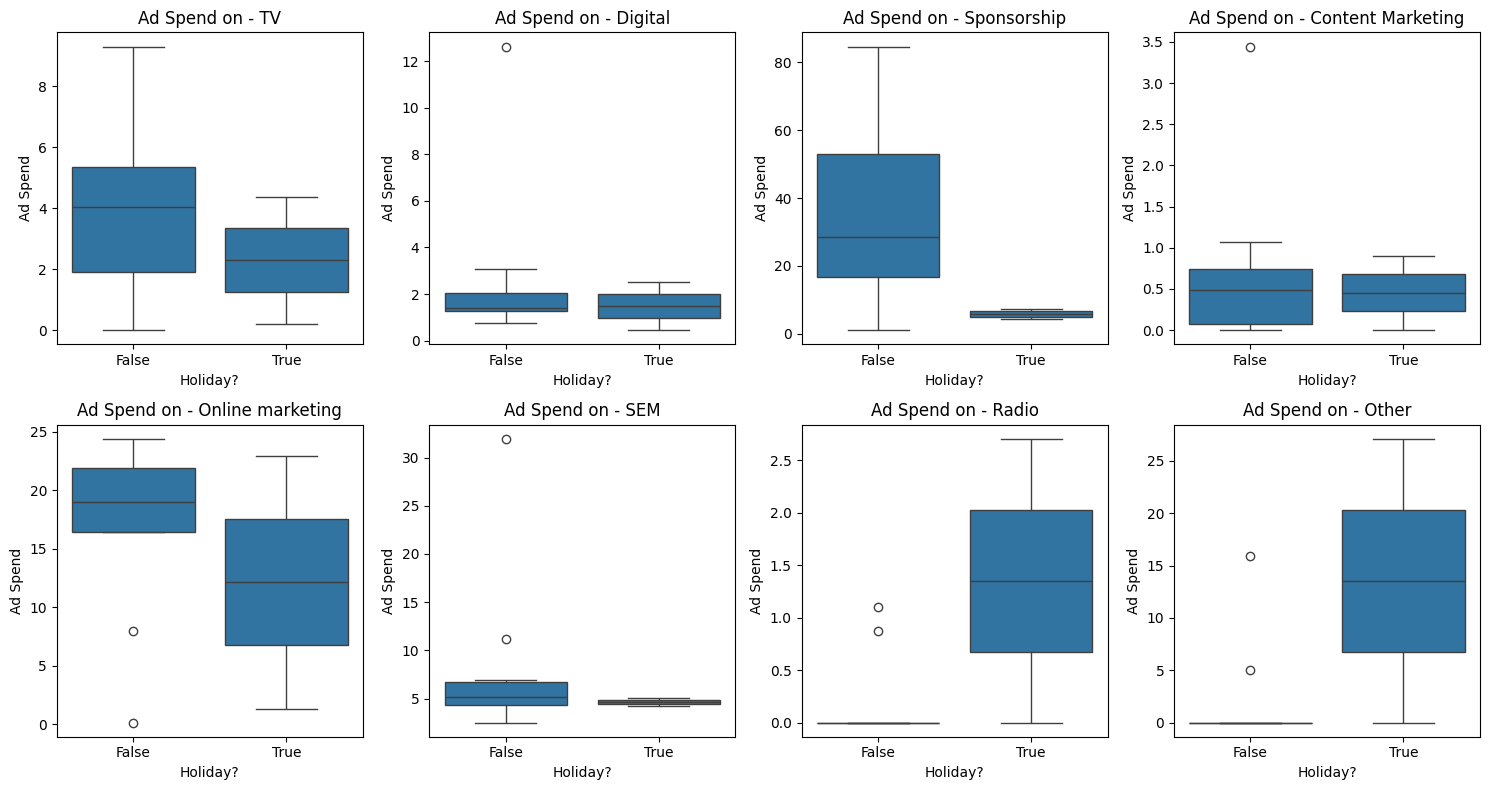

In [201]:
# Create a new column 'IsHoliday' in cac_df
cac_df['IsHoliday'] = cac_df['Date'].isin(canada_holiday['Day'])

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))
axes = axes.flatten()

# Iterate through marketing channels
for i, channel in enumerate(media_categories):
  # Filter data for current channel
  channel_data = cac_df[[channel, 'IsHoliday']]

  # Create boxplot for holiday/non-holiday ad spend for the channel
  sns.boxplot(x='IsHoliday', y=channel, data=channel_data, ax=axes[i])
  axes[i].set_title(f'Ad Spend on - {channel}')
  axes[i].set_xlabel('Holiday?')
  axes[i].set_ylabel('Ad Spend')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### Key Insights

- **TV & Sponsorship**: Higher spend outside holidays.
- **Online & Other Channels**: Increased spend during holidays.
- **Digital & Content Marketing**: Consistent spend year-round.
- **Radio**: Slightly higher spend during holidays.

#### Takeaway

- **Non-Holiday Focus**: Invest more in TV and Sponsorship.
- **Holiday Strategy**: Boost Online and Other channel spending.

### Bivariate analysis between Sales and Order(units sold) in months and spendings in months; also with luxury-mass market and spending comparison

In [202]:
# Dataframe with columns product_type, year, month, total gmv for year-month and total orders for year-month
gmv_orders_prodtype = cust_orders.groupby([cust_orders['product_type'], cust_orders['order_date'].dt.year, cust_orders['order_date'].dt.month]) \
    .agg({'gmv': 'sum', 'order_id': 'count'})

# Rename columns
gmv_orders_prodtype = gmv_orders_prodtype.rename(columns={'gmv': 'Total GMV', 'order_id': 'Total Orders'})

# Reset index to make 'product_analytic_category', 'year', and 'month' as columns
# Specify names for the index levels to avoid conflicts
gmv_orders_prodtype = gmv_orders_prodtype.reset_index(names=['product_type', 'Year', 'Month'])

# Print the new DataFrame
gmv_orders_prodtype

,product_type,Year,Month,Total GMV,Total Orders
0,Luxury,2023,5,3.149000e+03,1
1,Luxury,2023,6,2.800000e+03,1
2,Luxury,2023,7,9.930889e+07,14902
3,Luxury,2023,8,1.090790e+05,22
4,Luxury,2023,9,1.243372e+08,16986
5,Luxury,2023,10,2.625191e+08,29063
6,Luxury,2023,11,1.937219e+08,18821
7,Luxury,2023,12,2.305446e+08,23317
8,Luxury,2024,1,2.098454e+08,20929
9,Luxury,2024,2,1.766769e+08,18208


In [203]:
luxury_gmv_orders = gmv_orders_prodtype[gmv_orders_prodtype['product_type'] == 'Luxury']
mm_gmv_orders = gmv_orders_prodtype[gmv_orders_prodtype['product_type'] == 'Mass Market']
luxury_gmv_orders.head()

,product_type,Year,Month,Total GMV,Total Orders
0,Luxury,2023,5,3.149000e+03,1
1,Luxury,2023,6,2.800000e+03,1
2,Luxury,2023,7,9.930889e+07,14902
3,Luxury,2023,8,1.090790e+05,22
4,Luxury,2023,9,1.243372e+08,16986


In [204]:
# Drop rows 0,1,14
#luxury_gmv_orders = luxury_gmv_orders.drop([0, 1, 14])

In [205]:
# Drop rows 15,28
#mm_gmv_orders = mm_gmv_orders.drop([15, 28])

In [206]:
# Merge these with inv_stk_nps_gmv, drop rows not present in either
merged_lux_invdf = pd.merge(luxury_gmv_orders, inv_stk_nps_gmv, on='Month', how='inner')
merged_mm_invdf = pd.merge(mm_gmv_orders, inv_stk_nps_gmv, on='Month', how='inner')
# 'on' specifies the column(s) to merge on
# 'how='inner'' means only rows present in both DataFrames will be kept

merged_lux_invdf.head()

,product_type,Year_x,Month,Total GMV,Total Orders,Year_y,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index,monthly_gmv_sum,ROI
0,Luxury,2023,5,3.149000e+03,1,2024,78.057000,1.370000,0.770000,31.680000,0.790000,23.650000,6.800000,6.910000,1.1,4.987,47.306951,1228,3.614201e+08,-53.697928
1,Luxury,2023,6,2.800000e+03,1,2024,42.834216,1.662717,1.420761,25.048541,0.045081,7.971300,2.768023,3.735516,0.0,0.000,50.516687,1194,2.765834e+08,-35.429340
2,Luxury,2023,7,9.930889e+07,14902,2023,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.0,0.000,54.599588,1177,1.474386e+08,-13.585407
3,Luxury,2023,8,1.090790e+05,22,2023,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.0,0.000,59.987101,1206,2.015590e+05,-99.602001
4,Luxury,2023,9,1.243372e+08,16986,2023,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.0,0.000,46.925419,1101,1.774255e+08,-81.567023


In [207]:
def plot_twin_graphs(df, marketing_channel):
  """
  Plots twin graphs for Total GMV vs month and investment vs month, and
  Total Orders vs month and investment vs month for a given marketing channel.
  """

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

  # Plot 1: Total GMV vs month and investment vs month
  ax1 = axes[0]
  ax2 = ax1.twinx()

  ax1.bar(df['Month'], df['Total GMV'], label='Total GMV', color='blue', alpha=0.4, edgecolor='blue')
  ax2.bar(df['Month'], df[marketing_channel], label='Investment', color='red', facecolor='none', edgecolor='red')

  ax1.set_xlabel('Month')
  ax1.set_ylabel('Total GMV', color='blue')
  ax2.set_ylabel('Investment', color='red')
  ax1.set_title(f'{marketing_channel}: Total GMV vs Investment')
  ax1.legend(loc='upper left')
  ax2.legend(loc='upper right')

  # Plot 2: Total Orders vs month and investment vs month
  ax1 = axes[1]
  ax2 = ax1.twinx()

  ax1.bar(df['Month'], df['Total Orders'], label='Total Orders', color='green', alpha=0.4, edgecolor='green')
  ax2.bar(df['Month'], df[marketing_channel], label='Investment', color='red', facecolor='none', edgecolor='red')

  ax1.set_xlabel('Month')
  ax1.set_ylabel('Total Orders', color='green')
  ax2.set_ylabel('Investment', color='red')
  ax1.set_title(f'{marketing_channel}: Total Orders vs Investment')
  ax1.legend(loc='upper left')
  ax2.legend(loc='upper right')


  plt.tight_layout()
  plt.show()

Select from options of marketing channels to display GMV and Orders vs Month, for Luxury products.

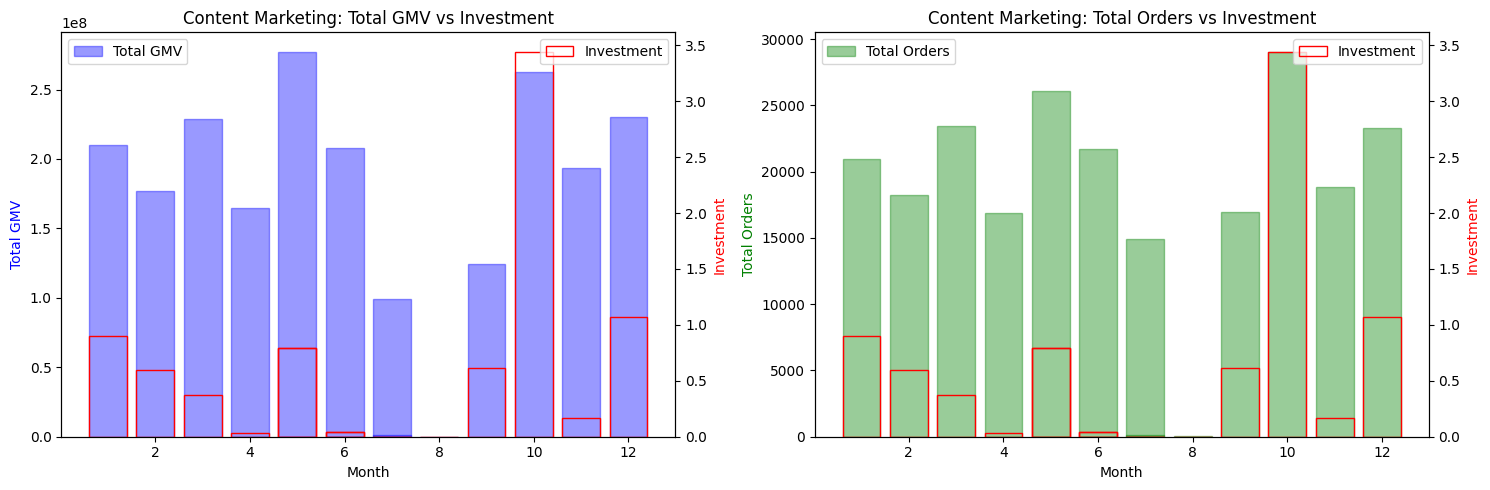

In [208]:
marketing_channel = "Content Marketing" #@param ["TV", "Digital", "Sponsorship", "Content Marketing", "Online marketing", " Affiliates", "SEM", "Radio", "Other"]

if marketing_channel in merged_lux_invdf.columns:
  plot_twin_graphs(merged_lux_invdf, marketing_channel)
else:
  print(f"Marketing channel '{marketing_channel}' not found in the data.")


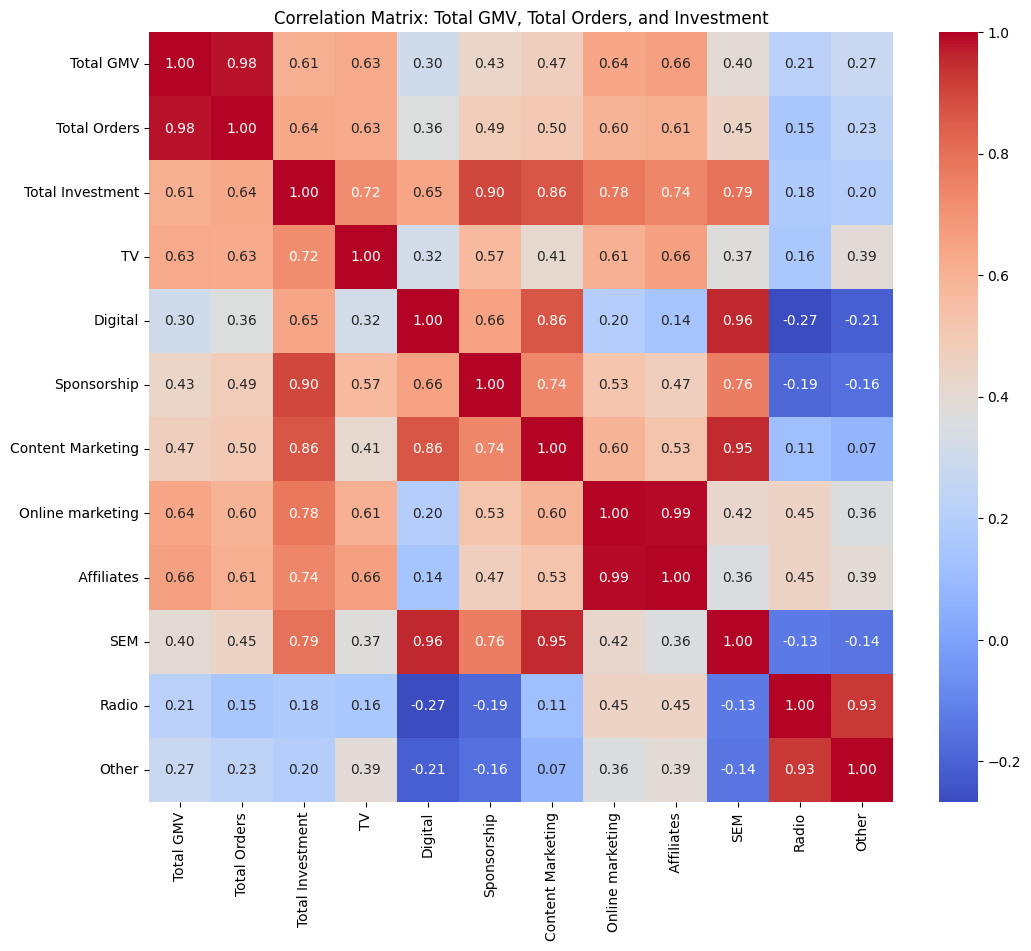

In [209]:
# Correlation between Total GMV, Total Orders and Total Investment for Luxury Items

correlation_matrix = merged_lux_invdf[['Total GMV', 'Total Orders', 'Total Investment', 'TV', 'Digital', 'Sponsorship',
                             'Content Marketing', 'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Total GMV, Total Orders, and Investment')
plt.show()

Select from options of marketing channels to display GMV and Orders vs Month, for Mass-Market products.

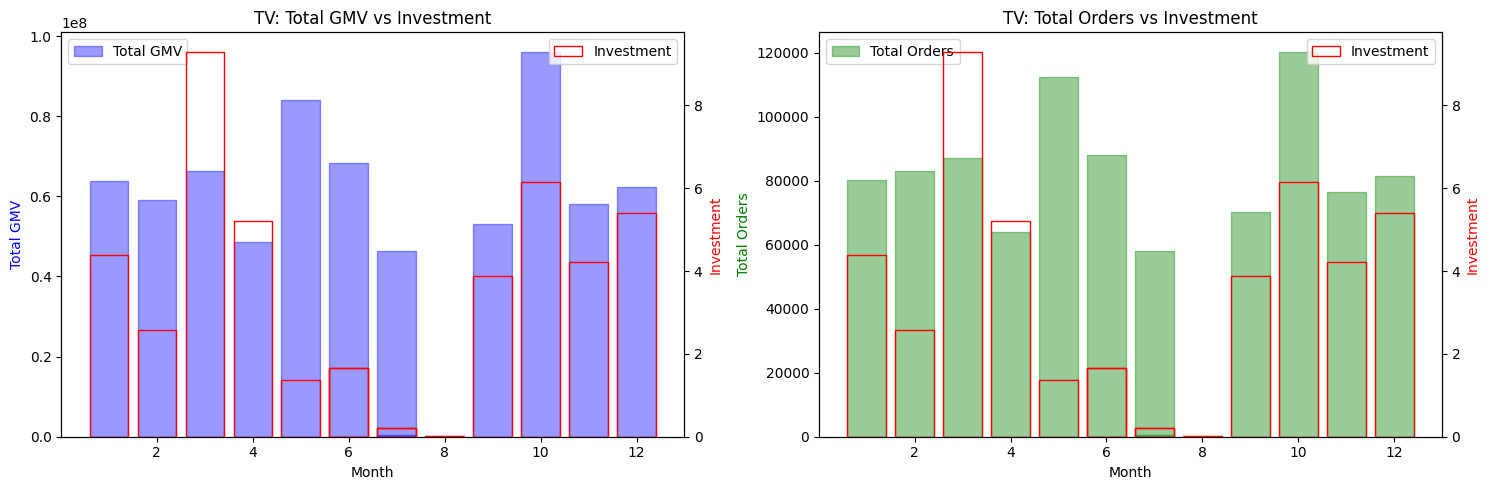

In [210]:
marketing_channel = "TV" #@param ["TV", "Digital", "Sponsorship", "Content Marketing", "Online marketing", " Affiliates", "SEM", "Radio", "Other"]

if marketing_channel in merged_mm_invdf.columns:
  plot_twin_graphs(merged_mm_invdf, marketing_channel)
else:
  print(f"Marketing channel '{marketing_channel}' not found in the data.")

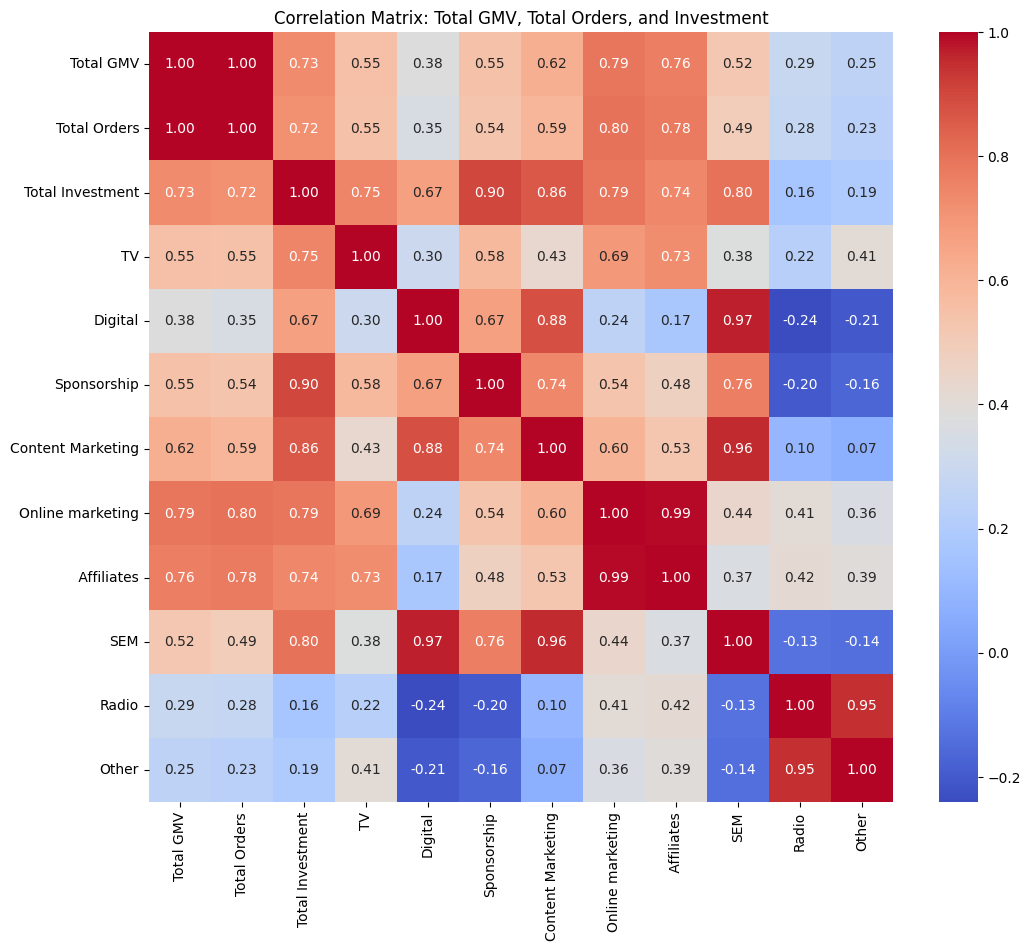

In [211]:
# Correlation between Total GMV, Total Orders and Total Investment for Mass Market Items

correlation_matrix = merged_mm_invdf[['Total GMV', 'Total Orders', 'Total Investment', 'TV', 'Digital', 'Sponsorship',
                             'Content Marketing', 'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Total GMV, Total Orders, and Investment')
plt.show()

### ROI Analysis based on Investment

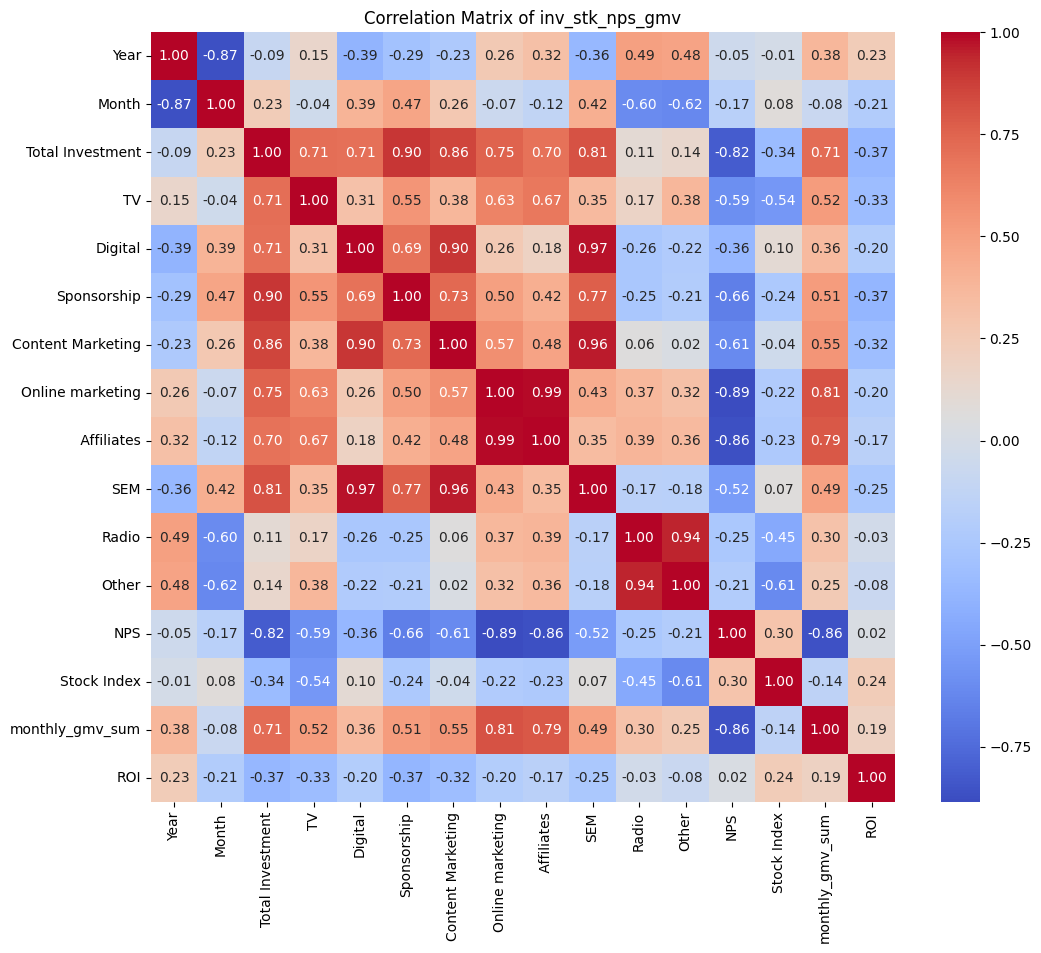

In [212]:
# Calculate the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(inv_stk_nps_gmv.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of inv_stk_nps_gmv')
plt.show()

In [213]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [214]:

def get_importances(X, y):
    # Train a Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Adjust n_estimators as needed
    rf_model.fit(X, y)

    # Get feature importances
    importances = rf_model.feature_importances_

    # Create a DataFrame for feature importances
    feature_importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

    # Plot feature importances
    plt.figure(figsize=(7, 5))
    plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importances with Random Forest')
    plt.show()

Analysing impact of marketing channel on ROI based on feature importances of Random Forest.

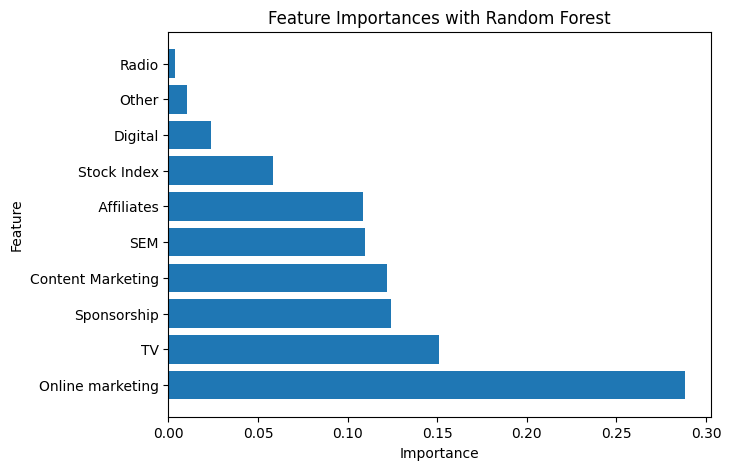

In [215]:
X = inv_stk_nps_gmv.drop(['monthly_gmv_sum', 'Total Investment', 'Year', 'Month', 'ROI', 'NPS'], axis=1)
y = inv_stk_nps_gmv['monthly_gmv_sum']
get_importances(X, y)

#### Intuition Behind ROI and Feature Importance

In a linear model, the Return on Investment (ROI) is expressed as:

$$ \text{ROI} = w_1x_1 + w_2x_2 + \ldots + b $$

Where:

- The magnitude of each weight \( w \) indicates the importance of the corresponding feature. A larger absolute value of \( w \) suggests a greater impact on ROI.
- The sign of each weight \( w \) indicates the relationship direction: a **positive weight** means an increase in the feature \( x \) leads to an increase in ROI, while a **negative weight** indicates the opposite.

In [216]:
inv_stk_nps_gmv.corr()['ROI']

,ROI
Year,0.234706
Month,-0.208319
Total Investment,-0.368786
TV,-0.330530
Digital,-0.200656
Sponsorship,-0.371431
Content Marketing,-0.323650
Online marketing,-0.203977
Affiliates,-0.171041
SEM,-0.250163


#### Possible reasons for negative impact on ROI:

1. **Market Saturation**:
   - In highly competitive markets, increased investment in marketing may not lead to significant gains if the market is saturated. This can cause ROI to decline as companies compete for the same audience.

2. **Misalignment with Customer Needs**:
   - If marketing efforts do not align with customer preferences or needs, they may fail to drive engagement or sales. This misalignment can lead to wasted resources and a negative impact on ROI.

A negative correlation between ROI and marketing channels suggests that increased investment in those channels may not be yielding the desired returns. It highlights the need for a thorough analysis of marketing strategies, customer alignment, and market conditions to optimize ROI effectively.

### Investment channels %age and returns

In [217]:
# Calculate average GMV for each channel across all months
avg_gmv_by_channel = inv_stk_nps_gmv.groupby('Month')[['TV', 'Digital', 'Sponsorship', 'Content Marketing',
                                                    'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']].mean()

# Calculate total spend across all channels for each month
total_spend_by_month = inv_stk_nps_gmv[['TV', 'Digital', 'Sponsorship', 'Content Marketing',
                                      'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']].sum(axis=1)

# Calculate ROI for each channel in each month
roi_by_channel = pd.DataFrame()
for channel in ['TV', 'Digital', 'Sponsorship', 'Content Marketing',
                'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']:
    roi_by_channel[channel] = (inv_stk_nps_gmv['monthly_gmv_sum'] / 1e7 - (inv_stk_nps_gmv[channel] + 1e-30)) / (inv_stk_nps_gmv[channel] + 1e-30)

# Calculate average ROI for each channel across all months
avg_roi_by_channel = roi_by_channel.mean()

# Calculate total budget average across all months
total_budget_avg = total_spend_by_month.mean()

# Calculate the percentage contribution of each channel to the total budget average
percentage_contribution = (avg_gmv_by_channel / total_budget_avg) * 100

print("Average ROI for each channel:")
print(avg_roi_by_channel)
print("\nPercentage contribution of each channel to the total budget average:")
print(percentage_contribution.mean())


Average ROI for each channel:
TV                   1.225537e+01
Digital              1.803109e+01
Sponsorship          4.474122e-01
Content Marketing    1.718040e+03
Online marketing     1.223396e+00
 Affiliates          5.262904e+00
SEM                  3.091959e+00
Radio                1.628595e+31
Other                1.628595e+31
dtype: float64

Percentage contribution of each channel to the total budget average:
TV                    5.242416
Digital               3.504578
Sponsorship          43.170937
Content Marketing     0.948565
Online marketing     22.879970
 Affiliates           7.251299
SEM                  10.776216
Radio                 0.551795
Other                 5.674223
dtype: float64


#### Analysis of ROI and Budget Contribution

1. **High ROI Channels**:
   - **Content Marketing**: Exhibits an exceptionally high ROI, suggesting that investments in this channel are yielding significant returns relative to the amount spent.
   - **Digital and TV**: Also show strong ROI, indicating effective use of budget in driving returns.

2. **Budget Allocation**:
   - **Sponsorship**: Consumes the largest portion of the budget (43.17%) but has a relatively low ROI, suggesting potential inefficiencies or areas for improvement.
   - **Online Marketing**: Takes up a significant budget share (22.88%) with moderate ROI, indicating room for optimization.

3. **Underutilized Channels**:
   - **Radio and Other**: Despite having a minimal budget allocation, these channels show extremely high ROI values, possibly due to data anomalies or calculation errors (e.g., the large ROI values might indicate a need for data review).

#### Strategic Recommendations

1. **Optimize Sponsorship Spending**: Re-evaluate the effectiveness of sponsorships and consider reallocating some of the budget to higher ROI channels like Content Marketing or Digital.

2. **Leverage High ROI Channels**: Increase investment in Content Marketing, Digital, and TV to capitalize on their strong returns.

3. **Balance Budget Allocation**: Consider a more balanced budget distribution that aligns with ROI performance, potentially improving overall efficiency and returns.


### Response curves
Showing how sales responds to spend for each marketing channel.

In [218]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [219]:
def plot_sales_vs_contribution_with_nonlinear_regression(df, channel):
  """
  Plots sales vs contribution for a given marketing channel and fits a non-linear regression curve.

  Args:
    df: The DataFrame containing sales and marketing spend data.
    channel: The name of the marketing channel.
  """

  # Assuming 'monthly_gmv_sum' is your sales column and 'channel' is your marketing spend column.
  X = df[[channel]]
  y = df['monthly_gmv_sum']

  # Create a polynomial regression model
  model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
  model.fit(X, y)

  # Generate predictions for a range of spend values
  X_range = np.linspace(X[channel].min(), X[channel].max(), 100).reshape(-1, 1)
  y_pred = model.predict(X_range)

  # Plot the data and the regression curve
  plt.figure(figsize=(8, 5))
  plt.scatter(X[channel], y, label='Data')
  plt.plot(X_range, y_pred, color='red', label='Non-linear Regression')
  plt.xlabel(channel)
  plt.ylabel('Sales (monthly_gmv_sum)')
  plt.title(f'Sales vs Contribution for {channel}')
  plt.legend()
  plt.show()

Select a marketing channel to see the response curve and its fitted line.

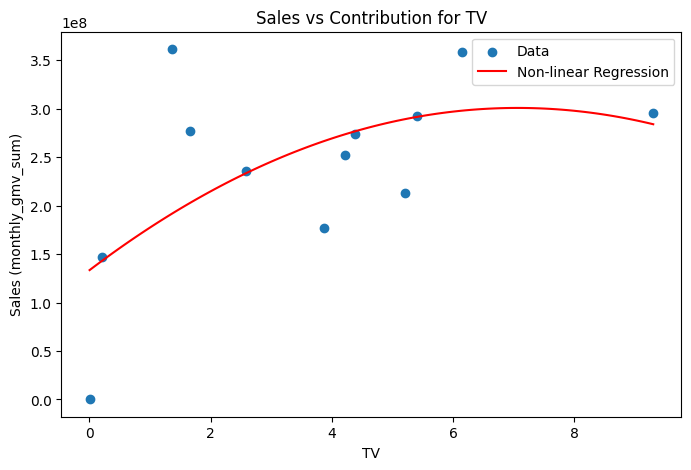

In [220]:
marketing_channel = "TV" #@param ["TV", "Digital", "Sponsorship", "Content Marketing", ' Affiliates', "Online marketing", "SEM", "Radio", "Other"]

plot_sales_vs_contribution_with_nonlinear_regression(inv_stk_nps_gmv, marketing_channel)

###----------------------------------------------------------------

## Models and Optimising Budget

### Creating Dataset for Pre-Training

In [221]:
cust_orders[['gmv', 'order_date']]

,gmv,order_date
0,3149.0,2023-05-19 13:42:09
1,275.0,2023-06-11 18:21:50
2,188.0,2023-06-24 10:20:16
3,250.0,2023-06-25 16:28:12
4,1119.0,2023-06-26 17:02:01
...,...,...
1152694,1548.0,2024-07-20 17:54:54
1152695,21495.0,2024-07-22 14:25:37
1152696,299.0,2024-07-24 14:03:57
1152697,439.0,2024-07-24 17:11:58


In [222]:
new_df = inv_stk_nps_gmv.copy()  # Create a copy to avoid modifying the original DataFrame

# Iterate through months and calculate the monthly investment channel data / 30
for month in new_df['Month'].unique():
  monthly_data = new_df[new_df['Month'] == month]
  for channel in ['TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']:
    new_df.loc[new_df['Month'] == month, channel] = monthly_data[channel].sum() / 30

new_df.head()

,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other,NPS,Stock Index,monthly_gmv_sum,ROI
1,2023,7,17.061775,0.007178,0.084434,0.247142,3.109658e-05,0.044243,0.018242,0.167457,0.0,0.0,54.599588,1177,1.474386e+08,-13.585407
2,2023,8,5.064306,0.000215,0.042602,0.035444,2.108377e-07,0.004308,0.002456,0.083784,0.0,0.0,59.987101,1206,2.015590e+05,-99.602001
3,2023,9,96.254380,0.129317,0.045218,2.092922,2.034307e-02,0.546000,0.167942,0.206738,0.0,0.0,46.925419,1101,1.774255e+08,-81.567023
4,2023,10,170.156297,0.204824,0.420749,2.822418,1.148025e-01,0.812393,0.232457,1.064234,0.0,0.0,44.398389,1210,3.586634e+08,-78.921531
5,2023,11,51.216220,0.140688,0.042516,0.472404,5.621106e-03,0.652052,0.219859,0.174068,0.0,0.0,47.000000,1233,2.518536e+08,-50.825423


In [223]:
dataset_gmvY = cust_orders[['gmv', 'order_date']]
dataset_gmvY.head()

,gmv,order_date
0,3149.0,2023-05-19 13:42:09
1,275.0,2023-06-11 18:21:50
2,188.0,2023-06-24 10:20:16
3,250.0,2023-06-25 16:28:12
4,1119.0,2023-06-26 17:02:01


In [224]:
# Assuming dataset_gmvY has unwanted dates so we remove them
dataset_gmvY['order_date'] = pd.to_datetime(dataset_gmvY['order_date'])
dataset_gmvY = dataset_gmvY[
    ~((dataset_gmvY['order_date'].dt.year == 2023) & (dataset_gmvY['order_date'].dt.month.isin([5, 6]))) &
    ~((dataset_gmvY['order_date'].dt.year == 2024) & (dataset_gmvY['order_date'].dt.month == 7))
]
dataset_gmvY

,gmv,order_date
7,305.0,2023-07-01 00:36:11
8,139.0,2023-07-01 00:38:19
9,385.0,2023-07-01 03:35:02
10,396.0,2023-07-01 05:30:28
11,99.0,2023-07-01 06:30:36
...,...,...
1152121,1747.0,2024-06-30 23:58:22
1152122,439.0,2024-06-30 23:58:39
1152123,7202.0,2024-06-30 23:58:57
1152124,1599.0,2024-06-30 23:59:26


In [225]:
# Assuming dataset_gmvY has unwanted dates so we remove them
cust_orders['order_date'] = pd.to_datetime(cust_orders['order_date'])
cust_orders = cust_orders[
    ~((cust_orders['order_date'].dt.year == 2023) & (cust_orders['order_date'].dt.month.isin([5, 6]))) &
    ~((cust_orders['order_date'].dt.year == 2024) & (cust_orders['order_date'].dt.month == 7))
]
cust_orders.head()

,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,...,list_price,product_analytic_super_category,product_analytic_category,product_analytic_sub_category,product_analytic_vertical,year,month,product_type,year_month,discount
7,AUDDGN3Q2GSCBUSX,2023-07-01 00:36:11,165147793.0,209706706.0,305.0,1,0,0,Prepaid,2.0,...,305.0,CE,EntertainmentSmall,AudioMP3Player,AudioMP3Player,2023,7,Mass Market,2023-07,72.272727
8,REME4AC4ENQGKWPB,2023-07-01 00:38:19,165148039.0,209707002.0,139.0,1,0,0,Prepaid,2.0,...,139.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,80.142857
9,ACCE5FQXQNRRGYNJ,2023-07-01 03:35:02,165165918.0,209727476.0,385.0,1,0,0,Prepaid,10.0,...,385.0,CE,GamingHardware,GamingAccessory,GamingMouse,2023,7,Mass Market,2023-07,44.921316
10,REME4AC4ENQGKWPB,2023-07-01 05:30:28,165169356.0,209731373.0,396.0,4,0,0,Prepaid,1.0,...,99.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,85.857143
11,REME4AC4ENQGKWPB,2023-07-01 06:30:36,165171457.0,209733747.0,99.0,1,0,0,Prepaid,1.0,...,99.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,85.857143


In [226]:
cust_orders

,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,...,list_price,product_analytic_super_category,product_analytic_category,product_analytic_sub_category,product_analytic_vertical,year,month,product_type,year_month,discount
7,AUDDGN3Q2GSCBUSX,2023-07-01 00:36:11,1.651478e+08,2.097067e+08,305.0,1,0,0,Prepaid,2.0,...,305.0,CE,EntertainmentSmall,AudioMP3Player,AudioMP3Player,2023,7,Mass Market,2023-07,72.272727
8,REME4AC4ENQGKWPB,2023-07-01 00:38:19,1.651480e+08,2.097070e+08,139.0,1,0,0,Prepaid,2.0,...,139.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,80.142857
9,ACCE5FQXQNRRGYNJ,2023-07-01 03:35:02,1.651659e+08,2.097275e+08,385.0,1,0,0,Prepaid,10.0,...,385.0,CE,GamingHardware,GamingAccessory,GamingMouse,2023,7,Mass Market,2023-07,44.921316
10,REME4AC4ENQGKWPB,2023-07-01 05:30:28,1.651694e+08,2.097314e+08,396.0,4,0,0,Prepaid,1.0,...,99.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,85.857143
11,REME4AC4ENQGKWPB,2023-07-01 06:30:36,1.651715e+08,2.097337e+08,99.0,1,0,0,Prepaid,1.0,...,99.0,CE,EntertainmentSmall,TVVideoSmall,RemoteControl,2023,7,Mass Market,2023-07,85.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1152121,AUDDM4XSFAHRNKJH,2024-06-30 23:58:22,1.641665e+15,1.641665e+15,1747.0,1,0,0,COD,6.0,...,1747.0,CE,EntertainmentSmall,AudioMP3Player,AudioMP3Player,2024,6,Mass Market,2024-06,96.506000
1152122,ACCEGDXHZA2PUD7B,2024-06-30 23:58:39,4.641665e+15,4.641665e+15,439.0,1,0,0,COD,7.0,...,439.0,CE,GamingHardware,GamingAccessory,GamingAccessoryKit,2024,6,Mass Market,2024-06,12.024048
1152123,CAMDTHSA6MFGKART,2024-06-30 23:58:57,1.641664e+15,1.641664e+15,7202.0,1,0,0,COD,6.0,...,7202.0,CE,Camera,Camera,Point & Shoot,2024,6,Luxury,2024-06,19.888765
1152124,ACCEEVPNDCFBQYCC,2024-06-30 23:59:26,1.641666e+15,1.641666e+15,1599.0,1,0,0,COD,5.0,...,1599.0,CE,EntertainmentSmall,Speaker,LaptopSpeaker,2024,6,Mass Market,2024-06,46.682227


In [227]:
"""for date in dataset_gmvY['order_date']:
  if date in cust_orders['order_date'].values:
    print(date)"""

"for date in dataset_gmvY['order_date']:\n  if date in cust_orders['order_date'].values:\n    print(date)"

In [228]:
cust_orders.columns

Index(['fsn_id', 'order_date', 'order_id', 'order_item_id', 'gmv', 'units',
       'deliverybdays', 'deliverycdays', 'order_payment_type', 'sla',
       'cust_id', 'pincode', 'product_mrp', 'product_procurement_sla',
       'list_price', 'product_analytic_super_category',
       'product_analytic_category', 'product_analytic_sub_category',
       'product_analytic_vertical', 'year', 'month', 'product_type',
       'year_month', 'discount'],
      dtype='object')

In [229]:
cust_orders.shape

(1152119, 24)

In [230]:
# Interpolating data for the marketing channels
for channel in ['TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']:
  # Create a new column in 'dataset_gmvY' for the current channel
  dataset_gmvY[channel] = np.nan

  # Iterate through rows in 'inv_stk_nps_gmv'
  for index, row in new_df.iterrows():
    # Extract the month from 'inv_stk_nps_gmv'
    month = row['Month']

    # Find rows in 'dataset_gmvY' with the same month
    matching_rows = dataset_gmvY[dataset_gmvY['order_date'].dt.month == month]

    if not matching_rows.empty:
      # Update the corresponding channel value in 'dataset_gmvY'
      dataset_gmvY.loc[matching_rows.index, channel] = row[channel]

# Now, 'dataset_gmvY' contains new columns for each marketing channel.
# The values in these columns are filled based on the matching month in 'inv_stk_nps_gmv'.

In [231]:
dataset_gmvY.head() # 1643311

,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
7,305.0,2023-07-01 00:36:11,0.007178,0.084434,0.247142,0.000031,0.044243,0.018242,0.167457,0.0,0.0
8,139.0,2023-07-01 00:38:19,0.007178,0.084434,0.247142,0.000031,0.044243,0.018242,0.167457,0.0,0.0
9,385.0,2023-07-01 03:35:02,0.007178,0.084434,0.247142,0.000031,0.044243,0.018242,0.167457,0.0,0.0
10,396.0,2023-07-01 05:30:28,0.007178,0.084434,0.247142,0.000031,0.044243,0.018242,0.167457,0.0,0.0
11,99.0,2023-07-01 06:30:36,0.007178,0.084434,0.247142,0.000031,0.044243,0.018242,0.167457,0.0,0.0


In [232]:
# Calculate the sum of marketing channels for each row
dataset_gmvY['marketing_channel_sum'] = dataset_gmvY[['TV', 'Digital', 'Sponsorship',
                                                  'Content Marketing', 'Online marketing', ' Affiliates',
                                                  'SEM', 'Radio', 'Other']].sum(axis=1)

# Find the minimum and maximum sum of marketing channels
min_sum = dataset_gmvY['marketing_channel_sum'].min()
max_sum = dataset_gmvY['marketing_channel_sum'].max()

print(f"Minimum sum of marketing channels: {min_sum}")
print(f"Maximum sum of marketing channels: {max_sum}")

Minimum sum of marketing channels: 0.16881020297389787
Maximum sum of marketing channels: 5.671876578944607


In [233]:
dataset_gmvY.shape

(1152119, 12)

In [234]:
cust_orders.columns

Index(['fsn_id', 'order_date', 'order_id', 'order_item_id', 'gmv', 'units',
       'deliverybdays', 'deliverycdays', 'order_payment_type', 'sla',
       'cust_id', 'pincode', 'product_mrp', 'product_procurement_sla',
       'list_price', 'product_analytic_super_category',
       'product_analytic_category', 'product_analytic_sub_category',
       'product_analytic_vertical', 'year', 'month', 'product_type',
       'year_month', 'discount'],
      dtype='object')

In [235]:
gmvY_= pd.merge(dataset_gmvY, cust_orders[['order_payment_type', 'product_type', 'discount', 'order_date','product_mrp', 'sla','product_procurement_sla',
       'list_price','product_analytic_category', 'product_analytic_sub_category']], on='order_date', how='right')

# Display the merged DataFrame
gmvY_.shape

(1152119, 21)

In [236]:
weather=pd.read_csv('/content/weather2023-2024.csv')

In [237]:
weather.drop(columns=['Dir of Max Gust (10s deg)','Spd of Max Gust (km/h)','Snow on Grnd (cm)','Heat Deg Days (°C)','Cool Deg Days (°C)', 'Total Precip (mm)'], inplace =True)

In [238]:
weather

,order_date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Total Rain (mm),Total Snow (cm)
0,2023-01-01,0.0,-8.5,-4.3,0.0,0.0
1,2023-01-02,3.0,-3.0,0.0,0.0,0.0
2,2023-01-03,2.5,-4.0,-0.8,24.0,0.0
3,2023-01-04,2.5,0.0,1.3,0.0,1.0
4,2023-01-05,-10.0,-13.5,-11.8,0.0,3.0
...,...,...,...,...,...,...
726,2024-12-27,0.5,-2.0,-0.8,0.0,0.0
727,2024-12-28,NaN,NaN,NaN,NaN,NaN
728,2024-12-29,6.0,-1.5,2.3,0.0,0.0
729,2024-12-30,2.5,-2.5,0.0,0.0,0.0


In [239]:
gmvY = pd.concat([gmvY_, weather], axis=1)

In [240]:
gmvY.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1152119 entries, 0 to 1152118
Data columns (total 27 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   gmv                            1152119 non-null  float64       
 1   order_date                     1152119 non-null  datetime64[ns]
 2   TV                             1152119 non-null  float64       
 3   Digital                        1152119 non-null  float64       
 4   Sponsorship                    1152119 non-null  float64       
 5   Content Marketing              1152119 non-null  float64       
 6   Online marketing               1152119 non-null  float64       
 7    Affiliates                    1152119 non-null  float64       
 8   SEM                            1152119 non-null  float64       
 9   Radio                          1152119 non-null  float64       
 10  Other                          1152119 non-null  float

In [241]:
# Step 1: Convert advertising spend columns to rupees (multiply by 10,000,000)
advertising_columns = ['TV', 'Digital', 'Sponsorship', 'Content Marketing',
                       'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other', 'marketing_channel_sum']

for col in advertising_columns:
    gmvY[col] = gmvY[col] * 10000000

# Step 2: Calculate ROI for each row
gmvY['ROI'] = (gmvY['gmv'] - gmvY['marketing_channel_sum']) / gmvY['marketing_channel_sum']

In [242]:
# Drop rows where 'product_procurement_sla' > 15
gmvY= gmvY[gmvY['product_procurement_sla'] <= 15]
gmvY= gmvY[gmvY['product_procurement_sla'] > 0]

# Drop rows where 'product_procurement_sla' > 15
gmvY= gmvY[gmvY['sla'] <= 50]
gmvY= gmvY[gmvY['sla'] >0]

# Optional: Reset the index after dropping rows
gmvY = gmvY.reset_index(drop=True)

In [243]:
gmvY

,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,...,list_price,product_analytic_category,product_analytic_sub_category,order_date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Total Rain (mm),Total Snow (cm),ROI
0,305.0,2023-07-01 00:36:11,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,305.0,EntertainmentSmall,AudioMP3Player,2023-01-01,0.0,-8.5,-4.3,0.0,0.0,-0.999946
1,139.0,2023-07-01 00:38:19,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,139.0,EntertainmentSmall,TVVideoSmall,2023-01-02,3.0,-3.0,0.0,0.0,0.0,-0.999976
2,385.0,2023-07-01 03:35:02,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,385.0,GamingHardware,GamingAccessory,2023-01-03,2.5,-4.0,-0.8,24.0,0.0,-0.999932
3,396.0,2023-07-01 05:30:28,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,99.0,EntertainmentSmall,TVVideoSmall,2023-01-04,2.5,0.0,1.3,0.0,1.0,-0.999930
4,99.0,2023-07-01 06:30:36,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,99.0,EntertainmentSmall,TVVideoSmall,2023-01-05,-10.0,-13.5,-11.8,0.0,3.0,-0.999983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064595,17500.0,2024-06-30 23:58:01,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,17500.0,GamingHardware,GamingConsole,NaN,NaN,NaN,NaN,NaN,NaN,-0.998769
1064596,1747.0,2024-06-30 23:58:22,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,1747.0,EntertainmentSmall,AudioMP3Player,NaN,NaN,NaN,NaN,NaN,NaN,-0.999877
1064597,439.0,2024-06-30 23:58:39,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,439.0,GamingHardware,GamingAccessory,NaN,NaN,NaN,NaN,NaN,NaN,-0.999969
1064598,7202.0,2024-06-30 23:58:57,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,7202.0,Camera,Camera,NaN,NaN,NaN,NaN,NaN,NaN,-0.999493


In [244]:
# Duplicates in order_date with exact same datetime in gmvY and drop the redundant rows
gmvY = gmvY.drop_duplicates()

In [245]:
gmvY.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064600 entries, 0 to 1064599
Data columns (total 28 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   gmv                            1064600 non-null  float64       
 1   order_date                     1064600 non-null  datetime64[ns]
 2   TV                             1064600 non-null  float64       
 3   Digital                        1064600 non-null  float64       
 4   Sponsorship                    1064600 non-null  float64       
 5   Content Marketing              1064600 non-null  float64       
 6   Online marketing               1064600 non-null  float64       
 7    Affiliates                    1064600 non-null  float64       
 8   SEM                            1064600 non-null  float64       
 9   Radio                          1064600 non-null  float64       
 10  Other                          1064600 non-null  float

In [ ]:
# Create a set of unique holiday week numbers from canada_holiday
holiday_weeks = set(canada_holiday['Week Number'])

# Create a new column 'Holiday Week' in gmvY, initialized to 0
gmvY['Holiday Week'] = 0

# Iterate through rows in gmvY
for index, row in gmvY.iterrows():
  # Check if the week number in gmvY is present in holiday_weeks
  if row['Week_Number'] in holiday_weeks:
    # If it's a holiday week, set 'Holiday Week' to 1
    gmvY.loc[index, 'Holiday Week'] = 1

# Now, 'gmvY' DataFrame has a new column 'Holiday Week'
# indicating whether a week is a holiday week or not (1 or 0).

In [247]:
# Drop rows where discount is not in range of 0 to 100
gmvY = gmvY[(gmvY['discount'] >= 0) & (gmvY['discount'] <= 100)]
gmvY.shape

(1044528, 28)

In [248]:
#gmvY.to_csv('gmvY.csv')

In [249]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

object_columns = ['order_payment_type', 'product_type', 'product_analytic_category']

# Initialize OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid multicollinearity

# Fit and transform the object columns
encoded_array = ohe.fit_transform(gmvY[object_columns])

# Get feature names after encoding
encoded_columns = ohe.get_feature_names_out(object_columns)

# Create a DataFrame for the encoded columns
encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)


In [250]:
gmvY


,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,...,list_price,product_analytic_category,product_analytic_sub_category,order_date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Total Rain (mm),Total Snow (cm),ROI
0,305.0,2023-07-01 00:36:11,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,305.0,EntertainmentSmall,AudioMP3Player,2023-01-01,0.0,-8.5,-4.3,0.0,0.0,-0.999946
1,139.0,2023-07-01 00:38:19,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,139.0,EntertainmentSmall,TVVideoSmall,2023-01-02,3.0,-3.0,0.0,0.0,0.0,-0.999976
2,385.0,2023-07-01 03:35:02,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,385.0,GamingHardware,GamingAccessory,2023-01-03,2.5,-4.0,-0.8,24.0,0.0,-0.999932
3,396.0,2023-07-01 05:30:28,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,99.0,EntertainmentSmall,TVVideoSmall,2023-01-04,2.5,0.0,1.3,0.0,1.0,-0.999930
4,99.0,2023-07-01 06:30:36,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,99.0,EntertainmentSmall,TVVideoSmall,2023-01-05,-10.0,-13.5,-11.8,0.0,3.0,-0.999983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064595,17500.0,2024-06-30 23:58:01,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,17500.0,GamingHardware,GamingConsole,NaN,NaN,NaN,NaN,NaN,NaN,-0.998769
1064596,1747.0,2024-06-30 23:58:22,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,1747.0,EntertainmentSmall,AudioMP3Player,NaN,NaN,NaN,NaN,NaN,NaN,-0.999877
1064597,439.0,2024-06-30 23:58:39,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,439.0,GamingHardware,GamingAccessory,NaN,NaN,NaN,NaN,NaN,NaN,-0.999969
1064598,7202.0,2024-06-30 23:58:57,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,7202.0,Camera,Camera,NaN,NaN,NaN,NaN,NaN,NaN,-0.999493


In [251]:
gmvY = gmvY.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

In [252]:
gmvY_encoded= pd.concat([gmvY, encoded_df], axis=1)

In [253]:

gmvY_encoded.drop(columns=['order_payment_type', 'list_price','product_type', 'product_analytic_sub_category','product_analytic_category'], inplace=True)

In [254]:
gmvY_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044528 entries, 0 to 1044527
Data columns (total 29 columns):
 #   Column                                        Non-Null Count    Dtype         
---  ------                                        --------------    -----         
 0   gmv                                           1044528 non-null  float64       
 1   order_date                                    1044528 non-null  datetime64[ns]
 2   TV                                            1044528 non-null  float64       
 3   Digital                                       1044528 non-null  float64       
 4   Sponsorship                                   1044528 non-null  float64       
 5   Content Marketing                             1044528 non-null  float64       
 6   Online marketing                              1044528 non-null  float64       
 7    Affiliates                                   1044528 non-null  float64       
 8   SEM                                       

In [255]:
gmvY.rename(columns={'order_date':'date'}, inplace= True)

In [256]:
gmvY_encoded

,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,...,Mean Temp (°C),Total Rain (mm),Total Snow (cm),ROI,order_payment_type_Prepaid,product_type_Mass Market,product_analytic_category_CameraAccessory,product_analytic_category_EntertainmentSmall,product_analytic_category_GameCDDVD,product_analytic_category_GamingHardware
0,305.0,2023-07-01 00:36:11,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-4.3,0.0,0.0,-0.999946,1.0,1.0,0.0,1.0,0.0,0.0
1,139.0,2023-07-01 00:38:19,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,0.0,0.0,0.0,-0.999976,1.0,1.0,0.0,1.0,0.0,0.0
2,385.0,2023-07-01 03:35:02,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-0.8,24.0,0.0,-0.999932,1.0,1.0,0.0,0.0,0.0,1.0
3,396.0,2023-07-01 05:30:28,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,1.3,0.0,1.0,-0.999930,1.0,1.0,0.0,1.0,0.0,0.0
4,99.0,2023-07-01 06:30:36,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-11.8,0.0,3.0,-0.999983,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044523,17500.0,2024-06-30 23:58:01,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.998769,0.0,0.0,0.0,0.0,0.0,1.0
1044524,1747.0,2024-06-30 23:58:22,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999877,0.0,1.0,0.0,1.0,0.0,0.0
1044525,439.0,2024-06-30 23:58:39,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999969,0.0,1.0,0.0,0.0,0.0,1.0
1044526,7202.0,2024-06-30 23:58:57,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999493,0.0,0.0,0.0,0.0,0.0,0.0


In [258]:
gmvY_encoded

,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,...,Mean Temp (°C),Total Rain (mm),Total Snow (cm),ROI,order_payment_type_Prepaid,product_type_Mass Market,product_analytic_category_CameraAccessory,product_analytic_category_EntertainmentSmall,product_analytic_category_GameCDDVD,product_analytic_category_GamingHardware
0,305.0,2023-07-01 00:36:11,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-4.3,0.0,0.0,-0.999946,1.0,1.0,0.0,1.0,0.0,0.0
1,139.0,2023-07-01 00:38:19,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,0.0,0.0,0.0,-0.999976,1.0,1.0,0.0,1.0,0.0,0.0
2,385.0,2023-07-01 03:35:02,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-0.8,24.0,0.0,-0.999932,1.0,1.0,0.0,0.0,0.0,1.0
3,396.0,2023-07-01 05:30:28,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,1.3,0.0,1.0,-0.999930,1.0,1.0,0.0,1.0,0.0,0.0
4,99.0,2023-07-01 06:30:36,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-11.8,0.0,3.0,-0.999983,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044523,17500.0,2024-06-30 23:58:01,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.998769,0.0,0.0,0.0,0.0,0.0,1.0
1044524,1747.0,2024-06-30 23:58:22,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999877,0.0,1.0,0.0,1.0,0.0,0.0
1044525,439.0,2024-06-30 23:58:39,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999969,0.0,1.0,0.0,0.0,0.0,1.0
1044526,7202.0,2024-06-30 23:58:57,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,NaN,NaN,NaN,-0.999493,0.0,0.0,0.0,0.0,0.0,0.0


In [259]:
#gmvY_encoded.to_csv('gmvY_encoded.csv')

In [260]:
gmvY_encoded =  gmvY_encoded.fillna(method='ffill')

gmvY_encoded= gmvY_encoded.fillna(method='bfill')


In [261]:
gmvY_encoded

,gmv,order_date,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,...,Mean Temp (°C),Total Rain (mm),Total Snow (cm),ROI,order_payment_type_Prepaid,product_type_Mass Market,product_analytic_category_CameraAccessory,product_analytic_category_EntertainmentSmall,product_analytic_category_GameCDDVD,product_analytic_category_GamingHardware
0,305.0,2023-07-01 00:36:11,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-4.3,0.0,0.0,-0.999946,1.0,1.0,0.0,1.0,0.0,0.0
1,139.0,2023-07-01 00:38:19,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,0.0,0.0,0.0,-0.999976,1.0,1.0,0.0,1.0,0.0,0.0
2,385.0,2023-07-01 03:35:02,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-0.8,24.0,0.0,-0.999932,1.0,1.0,0.0,0.0,0.0,1.0
3,396.0,2023-07-01 05:30:28,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,1.3,0.0,1.0,-0.999930,1.0,1.0,0.0,1.0,0.0,0.0
4,99.0,2023-07-01 06:30:36,71776.734654,844337.902816,2.471423e+06,310.965846,4.424259e+05,182417.952985,1.674566e+06,0.0,...,-11.8,0.0,3.0,-0.999983,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044523,17500.0,2024-06-30 23:58:01,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,2.3,0.0,0.0,-0.998769,0.0,0.0,0.0,0.0,0.0,1.0
1044524,1747.0,2024-06-30 23:58:22,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,2.3,0.0,0.0,-0.999877,0.0,1.0,0.0,1.0,0.0,0.0
1044525,439.0,2024-06-30 23:58:39,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,2.3,0.0,0.0,-0.999969,0.0,1.0,0.0,0.0,0.0,1.0
1044526,7202.0,2024-06-30 23:58:57,554238.961006,473586.835521,8.349514e+06,15026.875070,2.657100e+06,922674.353587,1.245172e+06,0.0,...,2.3,0.0,0.0,-0.999493,0.0,0.0,0.0,0.0,0.0,0.0


In [264]:
X= gmvY_encoded.drop(columns=['gmv','order_date'])
y= gmvY_encoded['gmv']

In [263]:
gmvY_encoded.to_csv('gmvY_encoded.csv')

In [266]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [267]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def train_and_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate their performance using R² score and MSE.

    Parameters:
    - X_train: Training features
    - y_train: Training target
    - X_test: Test features
    - y_test: Test target
    """

    # Dictionary to store results
    results = {}

    # List of models to train
    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Lasso Regression": Lasso(alpha=0.01, random_state=42),
        "Multiple Linear Regression": LinearRegression(),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "Linear Regression": LinearRegression(),
        "LightGBM": LGBMRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42)
    }

    # Train and evaluate each model
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Predict on the test set
        y_pred = model.predict(X_test)

        # Calculate R² score and MSE
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        # Store results
        results[model_name] = {"R² Score": r2, "MSE": mse}

        # Print results
        print(f"Model: {model_name}")
        print(f"R² Score: {r2:.4f}")
        print(f"MSE: {mse:.4f}")
        print("-" * 40)

    return results

# Example usage
# Assuming X_train, y_train, X_test, y_test are already defined
# results = train_and_evaluate_models(X_train, y_train, X_test, y_test)

In [268]:
train_and_evaluate_models(X_train, y_train, X_test, y_test)

Model: Decision Tree
R² Score: 0.9962
MSE: 102084.9613
----------------------------------------
Model: Lasso Regression
R² Score: 0.8942
MSE: 2848980.5706
----------------------------------------
Model: Multiple Linear Regression
R² Score: 0.8486
MSE: 4074827.7221
----------------------------------------
Model: AdaBoost
R² Score: 0.8743
MSE: 3383002.9552
----------------------------------------
Model: Linear Regression
R² Score: 0.8486
MSE: 4074827.7221
----------------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1021
[LightGBM] [Info] Number of data points in the train set: 731169, number of used features: 26
[LightGBM] [Info] Start training from score 2313.122978
Model: Ligh

{'Decision Tree': {'R² Score': 0.9962081348654066, 'MSE': 102084.96134915782},
 'Lasso Regression': {'R² Score': 0.8941768704044356,
  'MSE': 2848980.570552012},
 'Multiple Linear Regression': {'R² Score': 0.848643747672069,
  'MSE': 4074827.722085411},
 'AdaBoost': {'R² Score': 0.8743410313676787, 'MSE': 3383002.9551884816},
 'Linear Regression': {'R² Score': 0.848643747672069,
  'MSE': 4074827.722085411},
 'LightGBM': {'R² Score': 0.9957973098632655, 'MSE': 113145.23194850645},
 'Gradient Boosting': {'R² Score': 0.9914557504795363,
  'MSE': 230029.1152490158},
 'XGBoost': {'R² Score': 0.982515039520433, 'MSE': 470731.80384606734}}

In [269]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

def calculate_coefficients(X_train, y_train):
    """
    Calculate coefficients (or feature importance) for each column in the dataset for each algorithm.

    Parameters:
    - X_train: Training features
    - y_train: Training target

    Returns:
    - A dictionary containing coefficients/feature importance for each model.
    """

    # Dictionary to store coefficients/feature importance
    coefficients = {}

    # List of models to train
    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Lasso Regression": Lasso(alpha=0.01, random_state=42),
        "Multiple Linear Regression": LinearRegression(),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "Linear Regression": LinearRegression(),
        "XGBoost": XGBRegressor(random_state=42)
    }

    # Train each model and calculate coefficients/feature importance
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Get coefficients or feature importance
        if hasattr(model, 'coef_'):  # For linear models (Lasso, Linear Regression)
            coef = model.coef_
        elif hasattr(model, 'feature_importances_'):  # For tree-based models (Decision Tree, AdaBoost, XGBoost)
            coef = model.feature_importances_
        else:
            coef = None  # For models that don't provide coefficients/feature importance

        # Store coefficients/feature importance in a DataFrame
        if coef is not None:
            coef_df = pd.DataFrame({
                'Feature': X_train.columns,
                'Coefficient': coef
            }).sort_values(by='Coefficient', ascending=True)  # Sort in ascending order

            coefficients[model_name] = coef_df

        # Print coefficients/feature importance
        print(f"Model: {model_name}")
        if coef is not None:
            print(coef_df)
        else:
            print("This model does not provide coefficients or feature importance.")
        print("-" * 40)

    return coefficients

In [270]:
calculate_coefficients(X_train, y_train)

Model: Decision Tree
                                         Feature   Coefficient
18                               Total Snow (cm)  0.000000e+00
17                               Total Rain (mm)  4.647152e-13
16                                Mean Temp (°C)  1.904204e-11
14                                 Max Temp (°C)  1.520142e-09
15                                 Min Temp (°C)  1.627712e-09
24           product_analytic_category_GameCDDVD  9.168242e-07
20                    order_payment_type_Prepaid  6.436751e-06
22     product_analytic_category_CameraAccessory  8.671529e-06
7                                          Radio  2.070777e-05
23  product_analytic_category_EntertainmentSmall  2.094458e-05
8                                          Other  5.779310e-05
12                                           sla  9.815264e-05
4                               Online marketing  1.856900e-04
3                              Content Marketing  1.962345e-04
25      product_analytic_category_

{'Decision Tree':                                          Feature   Coefficient
 18                               Total Snow (cm)  0.000000e+00
 17                               Total Rain (mm)  4.647152e-13
 16                                Mean Temp (°C)  1.904204e-11
 14                                 Max Temp (°C)  1.520142e-09
 15                                 Min Temp (°C)  1.627712e-09
 24           product_analytic_category_GameCDDVD  9.168242e-07
 20                    order_payment_type_Prepaid  6.436751e-06
 22     product_analytic_category_CameraAccessory  8.671529e-06
 7                                          Radio  2.070777e-05
 23  product_analytic_category_EntertainmentSmall  2.094458e-05
 8                                          Other  5.779310e-05
 12                                           sla  9.815264e-05
 4                               Online marketing  1.856900e-04
 3                              Content Marketing  1.962345e-04
 25      product_analyt

**BUDGET OPTIMIZATION **
Budget Allocation Model

In [277]:
from scipy.optimize import minimize

In [276]:
# Find max and min values of each column in X and add in bound = [(min, max), ...]
def find_column_bounds(df):
  """
  Finds the minimum and maximum values for each column in a DataFrame.

  Args:
    df: The Pandas DataFrame.

  Returns:
    A list of tuples, where each tuple represents (min, max) for a column.
  """

  bounds = []
  for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
      min_val = df[column].min()
      max_val = df[column].max()
      bounds.append((min_val, max_val))
      print(f"Column '{column}' has range: ({min_val}, {max_val})")

  return bounds

if 'X' in locals():
    bound = find_column_bounds(X)

Column 'TV' has range: (2146.0243831843677, 3100000.0)
Column 'Digital' has range: (152000.0000000001, 4207493.255486052)
Column 'Sponsorship' has range: (354443.91935857356, 28224177.17542495)
Column 'Content Marketing' has range: (2.108376787197193, 1148024.9188951114)
Column 'Online marketing' has range: (43081.4213390103, 8123925.9123452)
Column ' Affiliates' has range: (24561.326765165624, 2456666.666666665)
Column 'SEM' has range: (837842.6681571692, 10642337.126386698)
Column 'Radio' has range: (0.0, 900000.0000000001)
Column 'Other' has range: (0.0, 9030000.000000007)
Column 'marketing_channel_sum' has range: (1688102.0297389787, 56718765.78944607)
Column 'discount' has range: (0.0, 100.0)
Column 'product_mrp' has range: (49, 299999)
Column 'sla' has range: (1.0, 46.0)
Column 'product_procurement_sla' has range: (1, 15)
Column 'Max Temp (°C)' has range: (-12.0, 35.0)
Column 'Min Temp (°C)' has range: (-24.0, 25.5)
Column 'Mean Temp (°C)' has range: (-18.0, 30.3)
Column 'Total R

In [279]:

# Calculate the sum of marketing channels for each row
gmvY['marketing_channel_sum'] = gmvY[['TV', 'Digital', 'Sponsorship',
                                                  'Content Marketing', 'Online marketing', ' Affiliates',
                                                  'SEM', 'Radio', 'Other']].sum(axis=1)

# Find the minimum and maximum sum of marketing channels
min_sum = gmvY['marketing_channel_sum'].min()
max_sum = gmvY['marketing_channel_sum'].max()

print(f"Minimum sum of marketing channels: {min_sum}")
print(f"Maximum sum of marketing channels: {max_sum}")
gmvY.drop(columns='marketing_channel_sum', axis=1, inplace=True)

Minimum sum of marketing channels: 1688102.029738979
Maximum sum of marketing channels: 56718765.78944607


In [284]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [288]:
LR = LinearRegression()
LR.fit(X_train, y_train)

LinearRegression()

In [289]:
# Define the objective function for optimization

marketing_channels = ['TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online marketing', 'Affiliates', 'SEM', 'Radio', 'Other']
Min_sum = 1397.7042236328125
Maxi_sum = 5687259.0
budget_allocation= [0.000026, 0.000171,-0.000101,  -0.000184,  -0.000013, -0.000355, -0.000254, 0.001190, -0.000216]
def objective(budget_allocation):
    # Create a sample input with the budget allocation
    sample = np.zeros(X.shape[1])
    sample[:9] = budget_allocation  # First 9 features are the marketing channels
    # Predict GMV
    predicted_gmv = LR.predict([sample])[0]
    return -predicted_gmv  # Negative because we want to maximize

# Constraints
def total_budget_constraint(x):
    return np.sum(x) - min_sum

def max_budget_constraint(x):
    return max_sum - np.sum(x)

# Bounds for each channel
bounds = bound[:9]

# Constraints dictionary
constraints = [
    {'type': 'ineq', 'fun': total_budget_constraint},
    {'type': 'ineq', 'fun': max_budget_constraint}
]

# Initial guess (equal distribution within bounds)
x0 = np.zeros(9)

# Perform the optimization
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

# Print the optimized allocation
print("Optimized allocation for each channel:")
channels = ['TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online Marketing', 'Affiliates', 'SEM', 'Radio', 'Other']
for channel, allocation in zip(channels, result.x):
    print(f"{channel}: {allocation:.6f}")

print("Maximum GMV (estimated):", -result.fun)

Optimized allocation for each channel:
TV: 147822.137117
Digital: 442495.557817
Sponsorship: 400099.431852
Content Marketing: 43039.124251
Online Marketing: 183469.001652
Affiliates: 24561.326797
SEM: 837842.668157
Radio: 899999.999999
Other: 3096.562743
Maximum GMV (estimated): 5993.40252036595


By optimizing the marketing budget allocation, the projected gmv is estimated to reach 5,993.40.
